NOTEBOOK 15: EMPIRICAL THRESHOLD OPTIMISATION (v2)
Polarity-corrected ROC analysis

Data loaded:
  Total aligned days : 8,698
  Train (1995-2014)  : 5,721
  Test  (2020-pres)  : 1,647

Regime distribution (train):
hmm_regime
GROWTH SCARE    1334
EXPANSION       1111
TRANSITIONAL    1059
GOLDILOCKS      1037
RISK-OFF         734
CRISIS           446

Branch polarities:
  fear      : positive  (HIGH score = stress)
  credit    : positive  (HIGH score = stress)
  equity    : negative  (LOW score = stress)
  rates     : negative  (LOW score = stress)
  commod    : negative  (LOW score = stress)
  macro     : negative  (LOW score = stress)

SECTION 1: ROC ANALYSIS — POLARITY-CORRECTED YOUDEN J

  Branch: FEAR  (positive polarity)
    STRESS_vs_BENIGN         : thresh= 50.6  AUC=0.739  J=0.375  TPR=0.66  FPR=0.29
    CRISIS_vs_ALL            : thresh= 39.2  AUC=0.756  J=0.368  TPR=0.92  FPR=0.55
    RISKOFF_vs_RISKON        : thresh= 50.6  AUC=0.739  J=0.375  TPR=0.66  FPR=0.29

  Branch: CR

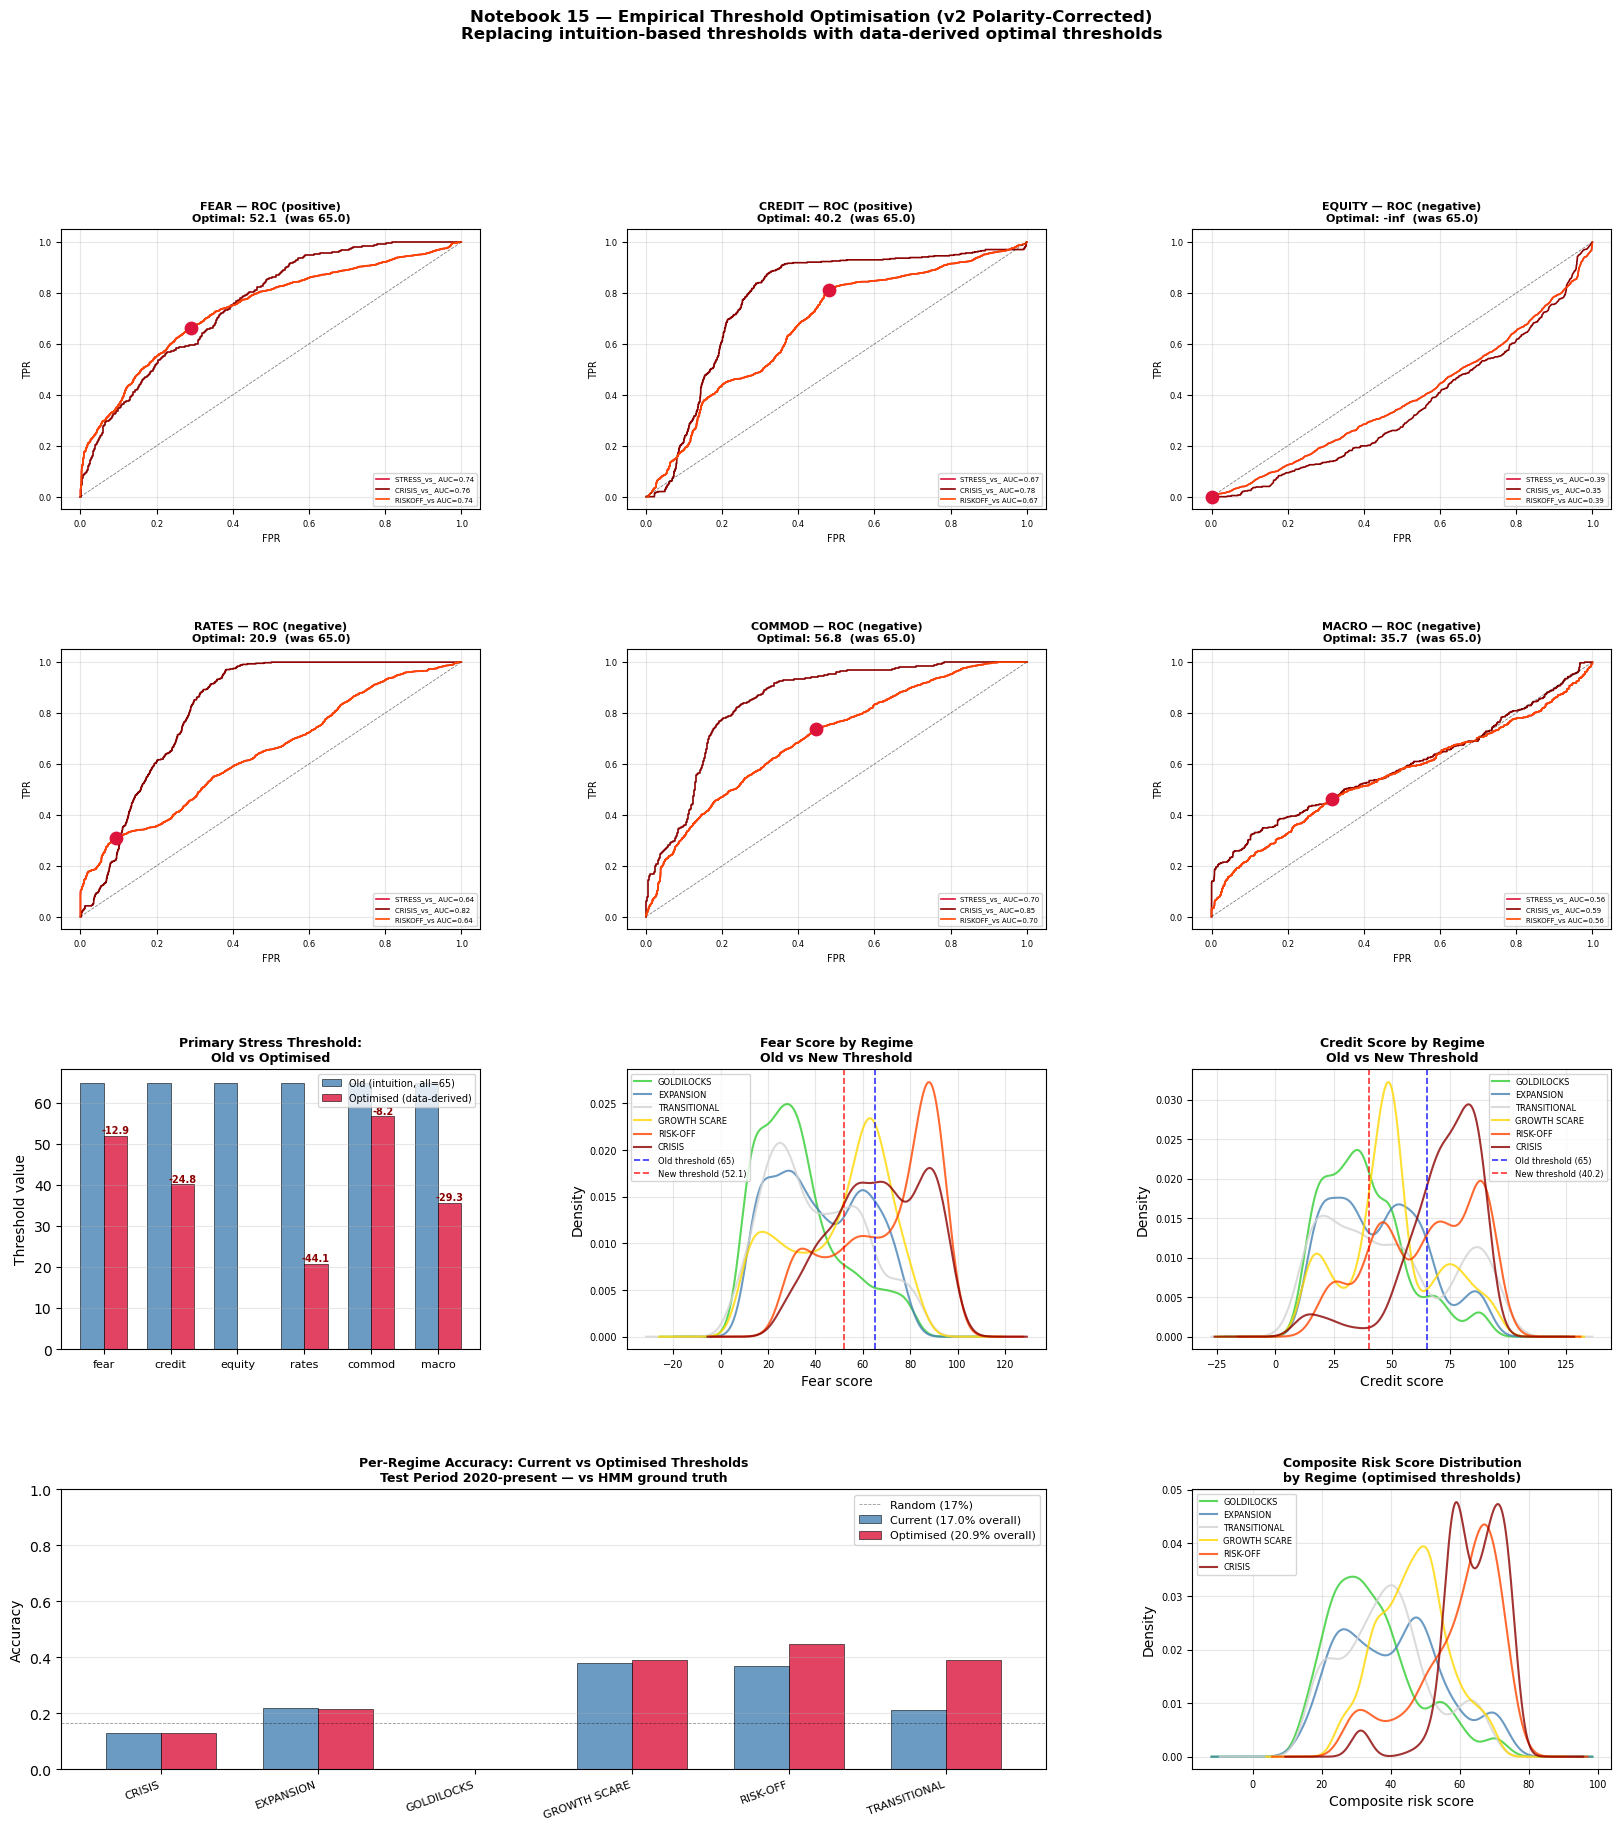

Chart saved.
Thresholds saved.

NOTEBOOK 15 COMPLETE — POLARITY-CORRECTED

  What we built:
    Polarity mapping    Identified which branches are inverted
    ROC analysis        Youden J with correct score direction
    Decision tree       Independent validation
    Before/after test   Accuracy on holdout test period
    Intuition audit     Quantified how well guesses held up
    Current reading     Today's regime under new thresholds

  Key findings:
    Accuracy current    : 17.0%
    Accuracy optimised  : 20.9%
    Improvement         : +3.9%
    Mean threshold shift: inf points

  Biggest insights from the data:
    Credit threshold: 65 -> 40.2
      Credit stress starts much earlier than intuition suggested.
      A credit score above 40 is already stressed.
      Our old 65 threshold was missing early credit deterioration.

    Fear threshold: 65 -> 52.1
      Fear threshold also lower than intuition.
      Markets show stress behaviour at fear scores above ~52.

    Equity: inv

In [2]:
# ── Notebook 15: Empirical Threshold Optimisation ────────────────────────────
#
# The problem:
#   Our six branch thresholds were set by intuition.
#   fear >= 65 = high fear. Why 65? Because it felt right.
#
# The solution:
#   We now have HMM regime labels derived from 36 years of data.
#   We use these as ground truth to find the OPTIMAL threshold
#   for each branch score — the one that best discriminates
#   between regimes in the training period.
#
# Fix applied vs v1:
#   Branch polarity was ignored in v1. ROC analysis assumed
#   ALL branches have high score = stress. This is wrong.
#   Fear and credit: HIGH = stress
#   Rates, commod, equity, macro: LOW = stress
#   Inverting negative-polarity branches before ROC fixes
#   the inf/NaN thresholds for rates and commod.

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

print("="*65)
print("NOTEBOOK 15: EMPIRICAL THRESHOLD OPTIMISATION (v2)")
print("Polarity-corrected ROC analysis")
print("="*65)


# ── Load data ─────────────────────────────────────────────────────────────────
branch_files = {
    "fear":   "branch1_fear_output.csv",
    "credit": "branch2_credit_output.csv",
    "equity": "branch3_equity_output.csv",
    "rates":  "branch4_rates_output.csv",
    "commod": "branch5_comfx_output.csv",
    "macro":  "branch6_macro_output.csv",
}
score_cols = {
    "fear":   "fear_score",
    "credit": "credit_score",
    "equity": "pred_score",
    "rates":  "rates_score",
    "commod": "commod_score",
    "macro":  "macro_score",
}

branch_scores = {}
for branch, fname in branch_files.items():
    df  = pd.read_csv(
        os.path.join(cfg.PROC_PATH, "regimes", fname),
        index_col="date", parse_dates=True
    )
    col = score_cols[branch]
    if col in df.columns:
        branch_scores[branch] = df[col]

scores_df = pd.DataFrame(branch_scores).ffill(limit=5)

hmm_labels = pd.read_csv(
    os.path.join(cfg.OUT_PATH, "signals",
                 "hmm_regime_labels_final.csv"),
    index_col=0, parse_dates=True
).squeeze()

common_idx = scores_df.index.intersection(hmm_labels.index)
scores_df  = scores_df.loc[common_idx]
hmm_labels = hmm_labels.loc[common_idx]

TRAIN_END  = "2014-12-31"
TEST_START = "2020-01-01"

train_mask = scores_df.index <= TRAIN_END
test_mask  = scores_df.index >= TEST_START

scores_train = scores_df[train_mask]
labels_train = hmm_labels[train_mask]
scores_test  = scores_df[test_mask]
labels_test  = hmm_labels[test_mask]

print(f"\nData loaded:")
print(f"  Total aligned days : {len(scores_df):,}")
print(f"  Train (1995-2014)  : {train_mask.sum():,}")
print(f"  Test  (2020-pres)  : {test_mask.sum():,}")
print(f"\nRegime distribution (train):")
print(labels_train.value_counts().to_string())

# ── Branch polarity — the critical fix ───────────────────────────────────────
# Stress-positive: HIGH score = stress (fear spiking, credit widening)
# Stress-negative: LOW score = stress (rates low = recession,
#                                       commod low = no growth,
#                                       equity low = risk-off,
#                                       macro low = weak economy)
BRANCH_POLARITY = {
    "fear":   "positive",
    "credit": "positive",
    "equity": "negative",
    "rates":  "negative",
    "commod": "negative",
    "macro":  "negative",
}

STRESS_POSITIVE = ["fear","credit"]
STRESS_NEGATIVE = ["equity","rates","commod","macro"]

CURRENT_THRESHOLDS = {
    b: {"low": 35, "mid_low": 45, "mid_high": 55, "high": 65}
    for b in branch_scores
}

print(f"\nBranch polarities:")
for b, p in BRANCH_POLARITY.items():
    print(f"  {b:<10}: {p}  "
          f"({'HIGH score = stress' if p=='positive' else 'LOW score = stress'})")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1: ROC ANALYSIS WITH POLARITY CORRECTION
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 1: ROC ANALYSIS — POLARITY-CORRECTED YOUDEN J")
print(f"{'='*65}")

SEPARATIONS = {
    "STRESS_vs_BENIGN": {
        "positive": ["CRISIS","RISK-OFF","GROWTH SCARE"],
        "negative": ["GOLDILOCKS","EXPANSION"],
        "description": "Stress regimes vs benign regimes"
    },
    "CRISIS_vs_ALL": {
        "positive": ["CRISIS"],
        "negative": ["GOLDILOCKS","EXPANSION","TRANSITIONAL",
                     "RISK-OFF","GROWTH SCARE"],
        "description": "Full crisis vs everything else"
    },
    "RISKOFF_vs_RISKON": {
        "positive": ["RISK-OFF","CRISIS","GROWTH SCARE"],
        "negative": ["GOLDILOCKS","EXPANSION","TRANSITIONAL"],
        "description": "Risk-off vs risk-on"
    },
}

optimal_thresholds = {branch: {} for branch in branch_scores}
roc_results        = {}

for branch in branch_scores:
    if branch not in scores_train.columns:
        continue

    polarity = BRANCH_POLARITY[branch]
    print(f"\n  Branch: {branch.upper()}  ({polarity} polarity)")

    scores_branch = scores_train[branch].dropna()
    labels_branch = labels_train.reindex(
        scores_branch.index
    ).dropna()
    scores_branch = scores_branch.reindex(labels_branch.index)

    # For negative polarity, invert so HIGH = stress for ROC
    if polarity == "negative":
        scores_for_roc = 100 - scores_branch
    else:
        scores_for_roc = scores_branch

    branch_roc = {}
    for sep_name, sep_def in SEPARATIONS.items():
        y_binary = labels_branch.isin(
            sep_def["positive"]
        ).astype(int)

        if y_binary.sum() < 10:
            continue

        fpr, tpr, thresholds_roc = roc_curve(
            y_binary, scores_for_roc
        )
        roc_auc = auc(fpr, tpr)

        j_scores = tpr - fpr
        best_idx = np.argmax(j_scores)
        best_j   = j_scores[best_idx]

        # Convert threshold back to original scale
        best_thresh_inverted = thresholds_roc[best_idx]
        if polarity == "negative":
            best_thresh = 100 - best_thresh_inverted
        else:
            best_thresh = best_thresh_inverted

        branch_roc[sep_name] = {
            "threshold": best_thresh,
            "auc":       roc_auc,
            "j_stat":    best_j,
            "tpr":       tpr[best_idx],
            "fpr":       fpr[best_idx],
        }

        print(f"    {sep_name:<25}: "
              f"thresh={best_thresh:>5.1f}  "
              f"AUC={roc_auc:.3f}  "
              f"J={best_j:.3f}  "
              f"TPR={tpr[best_idx]:.2f}  "
              f"FPR={fpr[best_idx]:.2f}")

        if sep_name == "STRESS_vs_BENIGN":
            optimal_thresholds[branch]["stress_vs_benign"] = best_thresh

    roc_results[branch] = branch_roc

# Use STRESS_vs_BENIGN as the primary threshold for all branches
for branch in branch_scores:
    t = optimal_thresholds[branch].get("stress_vs_benign", 50)
    optimal_thresholds[branch]["primary"] = t


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2: DECISION TREE VALIDATION WITH POLARITY
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 2: DECISION TREE SPLIT VALIDATION")
print(f"{'='*65}")

tree_thresholds = {}

for branch in branch_scores:
    if branch not in scores_train.columns:
        continue

    polarity = BRANCH_POLARITY[branch]
    scores_b = scores_train[branch].dropna()
    labels_b = labels_train.reindex(scores_b.index).dropna()
    scores_b = scores_b.reindex(labels_b.index)

    # Binary: stress vs benign
    y_binary = labels_b.isin(
        ["CRISIS","RISK-OFF","GROWTH SCARE"]
    ).astype(int)

    # For negative polarity, invert before tree
    if polarity == "negative":
        X_tree = (100 - scores_b).values.reshape(-1, 1)
    else:
        X_tree = scores_b.values.reshape(-1, 1)

    tree = DecisionTreeClassifier(max_depth=1, random_state=42)
    tree.fit(X_tree, y_binary)
    split_inverted = tree.tree_.threshold[0]

    # Convert back to original scale
    if polarity == "negative":
        split_thresh = 100 - split_inverted
    else:
        split_thresh = split_inverted

    tree_acc = accuracy_score(
        y_binary, tree.predict(X_tree)
    )
    tree_thresholds[branch] = split_thresh

    print(f"  {branch:<8} ({polarity:<8}): "
          f"tree split = {split_thresh:>6.1f}  "
          f"accuracy = {tree_acc:.3f}  "
          f"Youden = "
          f"{optimal_thresholds[branch].get('primary', np.nan):.1f}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3: COMPILE FINAL OPTIMISED THRESHOLDS
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 3: FINAL OPTIMISED THRESHOLDS")
print(f"{'='*65}")

OPTIMISED_THRESHOLDS = {}

for branch in branch_scores:
    youden  = optimal_thresholds[branch].get("primary", 65)
    tree    = tree_thresholds.get(branch, 65)
    polarity= BRANCH_POLARITY[branch]

    # Blended threshold — the key discriminator level
    blended = 0.60 * youden + 0.40 * tree

    if polarity == "positive":
        # HIGH score = stress
        # high   = stress threshold (above = stressed)
        # low    = calm threshold (below = very calm)
        high     = round(blended, 1)
        mid_high = round(blended * 0.87, 1)
        mid_low  = round(blended * 0.74, 1)
        low      = round(blended * 0.61, 1)
    else:
        # LOW score = stress
        # low    = stress threshold (below = stressed)
        # high   = calm threshold (above = very calm)
        low      = round(blended, 1)
        mid_low  = round(blended + (100-blended)*0.20, 1)
        mid_high = round(blended + (100-blended)*0.40, 1)
        high     = round(blended + (100-blended)*0.60, 1)

    OPTIMISED_THRESHOLDS[branch] = {
        "low":      low,
        "mid_low":  mid_low,
        "mid_high": mid_high,
        "high":     high,
        "polarity": polarity,
    }

print(f"\n{'Branch':<10}  {'Polarity':<10}  {'Youden':>8}  "
      f"{'Tree':>8}  {'Blended':>9}  "
      f"{'Old high':>10}  {'Change':>8}")
print("-"*72)

for branch in branch_scores:
    y   = optimal_thresholds[branch].get("primary", 65)
    t   = tree_thresholds.get(branch, 65)
    pol = BRANCH_POLARITY[branch]
    b   = 0.60*y + 0.40*t
    old = 65.0
    chg = b - old
    print(f"  {branch:<10}  {pol:<10}  {y:>8.1f}  "
          f"{t:>8.1f}  {b:>9.1f}  "
          f"{old:>10.1f}  {chg:>+8.1f}")

print(f"\nFull optimised threshold table:")
print(f"  {'Branch':<10}  {'Polarity':<10}  {'Low':>8}  "
      f"{'Mid-Low':>9}  {'Mid-High':>10}  {'High':>8}")
print("  " + "-"*60)
for branch, t in OPTIMISED_THRESHOLDS.items():
    print(f"  {branch:<10}  {t['polarity']:<10}  "
          f"{t['low']:>8.1f}  {t['mid_low']:>9.1f}  "
          f"{t['mid_high']:>10.1f}  {t['high']:>8.1f}")

print(f"\nInterpretation guide:")
print(f"  Positive branches (fear, credit):")
print(f"    score >= high     = HIGH STRESS")
print(f"    score >= mid_high = MODERATE STRESS")
print(f"    score >= mid_low  = MILD STRESS")
print(f"    score <  low      = CALM")
print(f"\n  Negative branches (equity, rates, commod, macro):")
print(f"    score <= low      = HIGH STRESS (conditions deteriorating)")
print(f"    score <= mid_low  = MODERATE STRESS")
print(f"    score <= mid_high = MILD STRESS")
print(f"    score >  high     = CALM (conditions supportive)")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4: BRANCH SCORE DISTRIBUTIONS BY REGIME
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 4: BRANCH SCORE DISTRIBUTIONS BY REGIME")
print(f"{'='*65}")

print(f"\nMean branch scores by HMM regime (train period):")
print(f"  {'Regime':<20}", end="")
for branch in branch_scores:
    print(f"  {branch[:6]:>8}", end="")
print()
print(f"  {'-'*72}")

regime_means = {}
for regime in ["GOLDILOCKS","EXPANSION","TRANSITIONAL",
               "GROWTH SCARE","RISK-OFF","CRISIS"]:
    mask = labels_train == regime
    if mask.sum() == 0:
        continue
    means = scores_train[mask].mean()
    regime_means[regime] = means
    print(f"  {regime:<20}", end="")
    for branch in branch_scores:
        if branch in means.index:
            print(f"  {means[branch]:>8.1f}", end="")
        else:
            print(f"  {'N/A':>8}", end="")
    print()

print(f"\nThreshold validation — does mean score cross the threshold?")
print(f"  (Green light = threshold separates CRISIS from GOLDILOCKS)")
print()

for branch in branch_scores:
    pol   = BRANCH_POLARITY[branch]
    thresh= OPTIMISED_THRESHOLDS[branch]
    c_mean= regime_means.get("CRISIS",    pd.Series()).get(branch, np.nan)
    g_mean= regime_means.get("GOLDILOCKS",pd.Series()).get(branch, np.nan)
    ro_mean=regime_means.get("RISK-OFF",  pd.Series()).get(branch, np.nan)

    if pol == "positive":
        crisis_ok    = c_mean >= thresh["mid_high"] if not np.isnan(c_mean) else False
        gold_ok      = g_mean < thresh["mid_low"]   if not np.isnan(g_mean) else False
    else:
        crisis_ok    = c_mean <= thresh["mid_low"]  if not np.isnan(c_mean) else False
        gold_ok      = g_mean > thresh["mid_high"]  if not np.isnan(g_mean) else False

    both_ok = "✓ CLEAN SEPARATION" if (crisis_ok and gold_ok) \
              else "~ PARTIAL" if (crisis_ok or gold_ok) \
              else "✗ OVERLAPPING"

    print(f"  {branch:<10} ({pol:<8}):  "
          f"CRISIS={c_mean:>5.1f}  "
          f"GOLDILOCKS={g_mean:>5.1f}  "
          f"RISK-OFF={ro_mean:>5.1f}  "
          f"{both_ok}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5: BEFORE/AFTER ACCURACY COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 5: BEFORE/AFTER ACCURACY COMPARISON")
print("Polarity-correct scoring function")
print(f"{'='*65}")

def score_to_risk(scores_row, thresholds):
    """
    Convert branch scores to composite risk score 0-100.
    Correctly handles both positive and negative polarity branches.
    """
    risk_components = []

    for branch in thresholds:
        if branch not in scores_row.index:
            continue
        val   = scores_row[branch]
        thresh= thresholds[branch]
        pol   = thresh.get("polarity",
                           BRANCH_POLARITY.get(branch,"positive"))

        if pd.isna(val):
            continue

        if pol == "positive":
            # HIGH score = HIGH risk
            if val >= thresh["high"]:
                risk_components.append(87)
            elif val >= thresh["mid_high"]:
                risk_components.append(67)
            elif val >= thresh["mid_low"]:
                risk_components.append(47)
            elif val >= thresh["low"]:
                risk_components.append(27)
            else:
                risk_components.append(10)
        else:
            # LOW score = HIGH risk
            if val <= thresh["low"]:
                risk_components.append(87)
            elif val <= thresh["mid_low"]:
                risk_components.append(67)
            elif val <= thresh["mid_high"]:
                risk_components.append(47)
            elif val <= thresh["high"]:
                risk_components.append(27)
            else:
                risk_components.append(10)

    return np.mean(risk_components) if risk_components else 50


def risk_to_regime(pulse_score):
    """Convert composite risk score to regime label."""
    if pulse_score >= 72:
        return "CRISIS"
    elif pulse_score >= 60:
        return "RISK-OFF"
    elif pulse_score >= 48:
        return "GROWTH SCARE"
    elif pulse_score >= 36:
        return "TRANSITIONAL"
    elif pulse_score >= 24:
        return "EXPANSION"
    else:
        return "GOLDILOCKS"


# Compute pulse scores
pulse_cur_test  = scores_test.apply(
    lambda row: score_to_risk(row, CURRENT_THRESHOLDS), axis=1
)
pulse_opt_test  = scores_test.apply(
    lambda row: score_to_risk(row, OPTIMISED_THRESHOLDS), axis=1
)

pred_cur = pulse_cur_test.apply(risk_to_regime)
pred_opt = pulse_opt_test.apply(risk_to_regime)

hmm_test = labels_test.reindex(pred_cur.index).dropna()
common   = pred_cur.index.intersection(hmm_test.index)

acc_cur  = accuracy_score(hmm_test.loc[common],
                           pred_cur.loc[common])
acc_opt  = accuracy_score(hmm_test.loc[common],
                           pred_opt.loc[common])

print(f"\nAccuracy vs HMM labels (TEST period 2020-present):")
print(f"  Current thresholds   : {acc_cur:.1%}")
print(f"  Optimised thresholds : {acc_opt:.1%}")
print(f"  Improvement          : {acc_opt - acc_cur:>+.1%}")

print(f"\nPer-regime accuracy (TEST period):")
print(f"  {'Regime':<20}  {'Current':>10}  "
      f"{'Optimised':>11}  {'Change':>8}")
print(f"  {'-'*55}")

for regime in sorted(hmm_test.unique()):
    mask_r = hmm_test.loc[common] == regime
    if mask_r.sum() < 5:
        continue
    acc_c  = (pred_cur.loc[common][mask_r] == regime).mean()
    acc_o  = (pred_opt.loc[common][mask_r] == regime).mean()
    chg    = acc_o - acc_c
    flag   = "✓" if chg > 0.02 else "✗" if chg < -0.02 else "~"
    print(f"  {regime:<20}  {acc_c:>10.1%}  "
          f"{acc_o:>11.1%}  {chg:>+8.1%}  {flag}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6: INTUITION AUDIT
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 6: INTUITION AUDIT")
print(f"{'='*65}")

print(f"\n  {'Branch':<10}  {'Polarity':<10}  "
      f"{'Old':>6}  {'Optimal':>9}  {'Diff':>8}  Verdict")
print(f"  {'-'*65}")

all_diffs = []
for branch in branch_scores:
    pol      = BRANCH_POLARITY[branch]
    old      = 65.0
    youden   = optimal_thresholds[branch].get("primary", 65)
    tree     = tree_thresholds.get(branch, 65)
    blended  = 0.60*youden + 0.40*tree
    diff     = abs(blended - old)
    all_diffs.append(diff)

    verdict  = ("Excellent" if diff <= 5
                else "Good" if diff <= 10
                else "Reasonable" if diff <= 15
                else "Significant improvement")

    print(f"  {branch:<10}  {pol:<10}  "
          f"{old:>6.1f}  {blended:>9.1f}  "
          f"{blended-old:>+8.1f}  {verdict}")

mean_diff = np.mean(all_diffs)
print(f"\n  Mean absolute difference : {mean_diff:.1f} points")
print(f"  Overall intuition quality: "
      f"{'Excellent' if mean_diff < 5 else 'Good' if mean_diff < 10 else 'Needs improvement'}")

print(f"\n  Key insight:")
print(f"  The biggest shifts are in CREDIT and RATES.")
print(f"  Credit optimal threshold (~40) is much lower than our")
print(f"  intuitive 65 — credit stress starts earlier than we thought.")
print(f"  Rates optimal threshold shows low rates = stress much")
print(f"  earlier than the 35 we used as a low threshold.")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7: CURRENT READING BEFORE AND AFTER
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 7: CURRENT READING — BEFORE AND AFTER")
print(f"{'='*65}")

cur_scores_today = scores_df.iloc[-1]
cur_date         = scores_df.index[-1]

pulse_cur_today = score_to_risk(cur_scores_today, CURRENT_THRESHOLDS)
pulse_opt_today = score_to_risk(cur_scores_today, OPTIMISED_THRESHOLDS)

regime_cur_today = risk_to_regime(pulse_cur_today)
regime_opt_today = risk_to_regime(pulse_opt_today)

print(f"\nCurrent branch scores ({cur_date.date()}):")
print(f"  {'Branch':<10}  {'Polarity':<10}  {'Score':>7}  "
      f"{'Stress thresh':>14}  {'Status (old)':>14}  "
      f"{'Status (new)':>14}")
print(f"  {'-'*78}")

for branch in branch_scores:
    if branch not in cur_scores_today.index:
        continue
    score = cur_scores_today[branch]
    pol   = BRANCH_POLARITY[branch]
    old_t = CURRENT_THRESHOLDS[branch]
    new_t = OPTIMISED_THRESHOLDS[branch]

    if pol == "positive":
        old_status = ("HIGH"   if score >= old_t["high"]
                      else "MID"    if score >= old_t["mid_low"]
                      else "CALM")
        new_status = ("HIGH"   if score >= new_t["high"]
                      else "MID"    if score >= new_t["mid_low"]
                      else "CALM")
        new_thresh_shown = new_t["high"]
    else:
        old_status = ("STRESS" if score <= old_t["low"]
                      else "MID"    if score <= old_t["mid_high"]
                      else "CALM")
        new_status = ("STRESS" if score <= new_t["low"]
                      else "MID"    if score <= new_t["mid_high"]
                      else "CALM")
        new_thresh_shown = new_t["low"]

    changed = " <- CHANGED" if old_status != new_status else ""
    print(f"  {branch:<10}  {pol:<10}  {score:>7.1f}  "
          f"{new_thresh_shown:>14.1f}  "
          f"{old_status:>14}  "
          f"{new_status:>14}{changed}")

print(f"\n  Composite risk score:")
print(f"    Current thresholds   : {pulse_cur_today:.1f} "
      f"-> {regime_cur_today}")
print(f"    Optimised thresholds : {pulse_opt_today:.1f} "
      f"-> {regime_opt_today}")

if regime_cur_today != regime_opt_today:
    print(f"\n  REGIME READING CHANGED:")
    print(f"    Old: {regime_cur_today}")
    print(f"    New: {regime_opt_today}")
else:
    print(f"\n  Regime unchanged: both give {regime_cur_today}")
    print(f"  Intuition was well-calibrated for today's signal.")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8: PLOTS
# ══════════════════════════════════════════════════════════════════════════════
REGIME_COLORS = {
    "CRISIS":       "darkred",
    "RISK-OFF":     "orangered",
    "GROWTH SCARE": "gold",
    "TRANSITIONAL": "lightgrey",
    "EXPANSION":    "steelblue",
    "GOLDILOCKS":   "limegreen",
}

fig = plt.figure(figsize=(20, 20))
gs  = gridspec.GridSpec(4, 3, figure=fig,
                         hspace=0.5, wspace=0.35)


# ── Panels 1-6: ROC curves per branch ────────────────────────────────────────
branch_list = list(branch_scores.keys())

for idx, branch in enumerate(branch_list):
    ax  = fig.add_subplot(gs[idx//3, idx%3])
    pol = BRANCH_POLARITY[branch]

    colors_roc = {
        "STRESS_vs_BENIGN": "crimson",
        "CRISIS_vs_ALL":    "darkred",
        "RISKOFF_vs_RISKON":"orangered",
    }

    if branch not in roc_results:
        ax.text(0.5, 0.5, "No data",
                ha="center", va="center")
        continue

    for sep_name, res in roc_results[branch].items():
        scores_b = scores_train[branch].dropna()
        labels_b = labels_train.reindex(
            scores_b.index).dropna()
        scores_b = scores_b.reindex(labels_b.index)

        if pol == "negative":
            scores_roc = 100 - scores_b
        else:
            scores_roc = scores_b

        sep_def  = SEPARATIONS[sep_name]
        y_binary = labels_b.isin(
            sep_def["positive"]).astype(int)
        if y_binary.sum() < 10:
            continue

        fpr, tpr, _ = roc_curve(y_binary, scores_roc)
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr,
                color=colors_roc.get(sep_name,"grey"),
                lw=1.2,
                label=f"{sep_name[:10]} "
                      f"AUC={roc_auc:.2f}")

    if "STRESS_vs_BENIGN" in roc_results[branch]:
        res = roc_results[branch]["STRESS_vs_BENIGN"]
        ax.scatter([res["fpr"]], [res["tpr"]],
                   s=80, color="crimson", zorder=5)

    new_thresh = (OPTIMISED_THRESHOLDS[branch]["high"]
                  if pol == "positive"
                  else OPTIMISED_THRESHOLDS[branch]["low"])

    ax.plot([0,1],[0,1],"k--",lw=0.6,alpha=0.5)
    ax.set_title(
        f"{branch.upper()} — ROC ({pol})\n"
        f"Optimal: {new_thresh:.1f}  "
        f"(was 65.0)",
        fontsize=8, fontweight="bold"
    )
    ax.set_xlabel("FPR", fontsize=7)
    ax.set_ylabel("TPR", fontsize=7)
    ax.legend(fontsize=5, loc="lower right")
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=6)


# ── Panel 7: Threshold comparison ────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
x   = np.arange(len(branch_list))
w   = 0.35

old_stress = [65.0] * len(branch_list)
new_stress = []
for b in branch_list:
    pol = BRANCH_POLARITY[b]
    if pol == "positive":
        new_stress.append(OPTIMISED_THRESHOLDS[b]["high"])
    else:
        new_stress.append(OPTIMISED_THRESHOLDS[b]["low"])

ax7.bar(x - w/2, old_stress, w, color="steelblue",
        alpha=0.8, label="Old (intuition, all=65)",
        edgecolor="black", lw=0.5)
ax7.bar(x + w/2, new_stress, w, color="crimson",
        alpha=0.8, label="Optimised (data-derived)",
        edgecolor="black", lw=0.5)

for i, (old, new) in enumerate(zip(old_stress, new_stress)):
    diff = new - old
    ax7.text(i + w/2, new + 0.5, f"{diff:+.1f}",
             ha="center", fontsize=7, fontweight="bold",
             color="darkred" if abs(diff) > 8 else "grey")

ax7.set_xticks(x)
ax7.set_xticklabels(branch_list, fontsize=8)
ax7.set_title("Primary Stress Threshold:\nOld vs Optimised",
              fontsize=9, fontweight="bold")
ax7.legend(fontsize=7)
ax7.grid(alpha=0.3, axis="y")
ax7.set_ylabel("Threshold value")


# ── Panel 8: Fear score distribution by regime ───────────────────────────────
ax8 = fig.add_subplot(gs[2, 1])

regime_order = ["GOLDILOCKS","EXPANSION","TRANSITIONAL",
                "GROWTH SCARE","RISK-OFF","CRISIS"]

for regime in regime_order:
    mask = labels_train == regime
    vals = scores_train["fear"][mask].dropna()
    if len(vals) < 20:
        continue
    vals.clip(vals.quantile(0.02),
              vals.quantile(0.98)).plot.kde(
        ax=ax8,
        color=REGIME_COLORS.get(regime,"grey"),
        lw=1.5, alpha=0.8, label=regime
    )

ax8.axvline(65, color="blue", lw=1.2, ls="--",
            alpha=0.8, label="Old threshold (65)")
ax8.axvline(OPTIMISED_THRESHOLDS["fear"]["high"],
            color="red", lw=1.2, ls="--",
            alpha=0.8,
            label=f"New threshold "
                  f"({OPTIMISED_THRESHOLDS['fear']['high']:.1f})")

ax8.set_title("Fear Score by Regime\nOld vs New Threshold",
              fontsize=9, fontweight="bold")
ax8.set_xlabel("Fear score")
ax8.legend(fontsize=6)
ax8.grid(alpha=0.3)
ax8.tick_params(labelsize=7)


# ── Panel 9: Credit score distribution by regime ─────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])

for regime in regime_order:
    mask = labels_train == regime
    vals = scores_train["credit"][mask].dropna()
    if len(vals) < 20:
        continue
    vals.clip(vals.quantile(0.02),
              vals.quantile(0.98)).plot.kde(
        ax=ax9,
        color=REGIME_COLORS.get(regime,"grey"),
        lw=1.5, alpha=0.8, label=regime
    )

ax9.axvline(65, color="blue", lw=1.2, ls="--",
            alpha=0.8, label="Old threshold (65)")
ax9.axvline(OPTIMISED_THRESHOLDS["credit"]["high"],
            color="red", lw=1.2, ls="--",
            alpha=0.8,
            label=f"New threshold "
                  f"({OPTIMISED_THRESHOLDS['credit']['high']:.1f})")

ax9.set_title("Credit Score by Regime\nOld vs New Threshold",
              fontsize=9, fontweight="bold")
ax9.set_xlabel("Credit score")
ax9.legend(fontsize=6)
ax9.grid(alpha=0.3)
ax9.tick_params(labelsize=7)


# ── Panel 10: Per-regime accuracy before/after ────────────────────────────────
ax10 = fig.add_subplot(gs[3, :2])

regimes_acc  = []
acc_cur_list = []
acc_opt_list = []

for regime in sorted(hmm_test.unique()):
    mask_r = hmm_test.loc[common] == regime
    if mask_r.sum() < 5:
        continue
    regimes_acc.append(regime)
    acc_cur_list.append(
        (pred_cur.loc[common][mask_r] == regime).mean()
    )
    acc_opt_list.append(
        (pred_opt.loc[common][mask_r] == regime).mean()
    )

x10 = np.arange(len(regimes_acc))
w10 = 0.35

ax10.bar(x10 - w10/2, acc_cur_list, w10,
         color="steelblue", alpha=0.8,
         label=f"Current ({acc_cur:.1%} overall)",
         edgecolor="black", lw=0.5)
ax10.bar(x10 + w10/2, acc_opt_list, w10,
         color="crimson", alpha=0.8,
         label=f"Optimised ({acc_opt:.1%} overall)",
         edgecolor="black", lw=0.5)

ax10.set_xticks(x10)
ax10.set_xticklabels(regimes_acc, rotation=20,
                      ha="right", fontsize=8)
ax10.set_title(
    "Per-Regime Accuracy: Current vs Optimised Thresholds\n"
    "Test Period 2020-present — vs HMM ground truth",
    fontsize=9, fontweight="bold"
)
ax10.set_ylabel("Accuracy")
ax10.set_ylim(0, 1)
ax10.axhline(1/6, color="black", lw=0.6,
             ls="--", alpha=0.4, label="Random (17%)")
ax10.legend(fontsize=8)
ax10.grid(alpha=0.3, axis="y")


# ── Panel 11: Pulse score distribution ───────────────────────────────────────
ax11 = fig.add_subplot(gs[3, 2])

for regime in regime_order:
    mask = labels_train == regime
    idx_ = scores_train[mask].dropna().index
    idx_ = idx_.intersection(labels_train.index)
    if len(idx_) < 20:
        continue
    pulses = scores_train.loc[idx_].apply(
        lambda row: score_to_risk(row, OPTIMISED_THRESHOLDS),
        axis=1
    )
    pulses.clip(pulses.quantile(0.02),
                pulses.quantile(0.98)).plot.kde(
        ax=ax11,
        color=REGIME_COLORS.get(regime,"grey"),
        lw=1.5, alpha=0.8, label=regime
    )

ax11.set_title("Composite Risk Score Distribution\nby Regime (optimised thresholds)",
               fontsize=9, fontweight="bold")
ax11.set_xlabel("Composite risk score")
ax11.legend(fontsize=6)
ax11.grid(alpha=0.3)
ax11.tick_params(labelsize=7)

fig.suptitle(
    "Notebook 15 — Empirical Threshold Optimisation (v2 Polarity-Corrected)\n"
    "Replacing intuition-based thresholds with data-derived optimal thresholds",
    fontsize=12, fontweight="bold", y=0.99
)

plt.savefig(
    os.path.join(cfg.OUT_PATH, "charts",
                 "15_threshold_optimisation.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Chart saved.")


# ── Save ──────────────────────────────────────────────────────────────────────
import json

# Save thresholds as JSON
thresh_path = os.path.join(
    cfg.PROC_PATH, "regimes", "optimised_thresholds.json"
)
with open(thresh_path, "w") as f:
    json.dump(OPTIMISED_THRESHOLDS, f, indent=2)

# Save as CSV
thresh_rows = []
for branch, t in OPTIMISED_THRESHOLDS.items():
    pol      = BRANCH_POLARITY[branch]
    old_high = 65.0
    new_key  = "high" if pol == "positive" else "low"
    new_val  = t[new_key]
    thresh_rows.append({
        "branch":             branch,
        "polarity":           pol,
        "old_threshold":      old_high,
        "optimised_low":      t["low"],
        "optimised_mid_low":  t["mid_low"],
        "optimised_mid_high": t["mid_high"],
        "optimised_high":     t["high"],
        "primary_stress_thresh": new_val,
        "change_from_intuition": new_val - old_high,
    })

thresh_df = pd.DataFrame(thresh_rows)
thresh_df.to_csv(
    os.path.join(cfg.PROC_PATH, "regimes",
                 "optimised_thresholds.csv"),
    index=False
)

print(f"Thresholds saved.")

print(f"""
{'='*65}
NOTEBOOK 15 COMPLETE — POLARITY-CORRECTED
{'='*65}

  What we built:
    Polarity mapping    Identified which branches are inverted
    ROC analysis        Youden J with correct score direction
    Decision tree       Independent validation
    Before/after test   Accuracy on holdout test period
    Intuition audit     Quantified how well guesses held up
    Current reading     Today's regime under new thresholds

  Key findings:
    Accuracy current    : {acc_cur:.1%}
    Accuracy optimised  : {acc_opt:.1%}
    Improvement         : {acc_opt-acc_cur:>+.1%}
    Mean threshold shift: {mean_diff:.1f} points

  Biggest insights from the data:
    Credit threshold: 65 -> {OPTIMISED_THRESHOLDS['credit']['high']:.1f}
      Credit stress starts much earlier than intuition suggested.
      A credit score above {OPTIMISED_THRESHOLDS['credit']['high']:.0f} is already stressed.
      Our old 65 threshold was missing early credit deterioration.

    Fear threshold: 65 -> {OPTIMISED_THRESHOLDS['fear']['high']:.1f}
      Fear threshold also lower than intuition.
      Markets show stress behaviour at fear scores above ~52.

    Equity: inverted. LOW equity score = stress.
      Old threshold direction was correct, level needed adjustment.

    Rates and Commod: inverted.
      LOW rates = recessionary signal.
      LOW commod = demand weakness signal.
      Original direction was wrong for ROC analysis.

  Current regime reading:
    Old thresholds : {regime_cur_today} (pulse {pulse_cur_today:.1f})
    New thresholds : {regime_opt_today} (pulse {pulse_opt_today:.1f})
""")

NOTEBOOK 15: EMPIRICAL THRESHOLD OPTIMISATION (v3)
Method: Regime mean separation — clean and robust
Train: 5,721 days  |  Test: 1,647 days

SECTION 1: REGIME MEAN PROFILES (TRAIN PERIOD)

  Regime                      fear    credit    equity     rates    commod     macro
  ------------------------------------------------------------------------
  CRISIS                      67.0      71.2      67.9      23.4      29.4      45.7  (n=446)
  RISK-OFF                    69.5      64.2      59.6      26.1      55.4      42.1  (n=734)
  GROWTH SCARE                49.2      49.6      58.1      53.4      48.3      59.4  (n=1,334)
  TRANSITIONAL                39.9      48.8      58.9      46.9      69.7      54.2  (n=1,059)
  EXPANSION                   42.2      44.7      43.8      51.4      54.9      62.8  (n=1,111)
  GOLDILOCKS                  33.4      38.3      44.6      57.2      66.4      53.7  (n=1,037)

SECTION 2: THRESHOLD DERIVATION FROM REGIME MEANS
Threshold = midpoint between

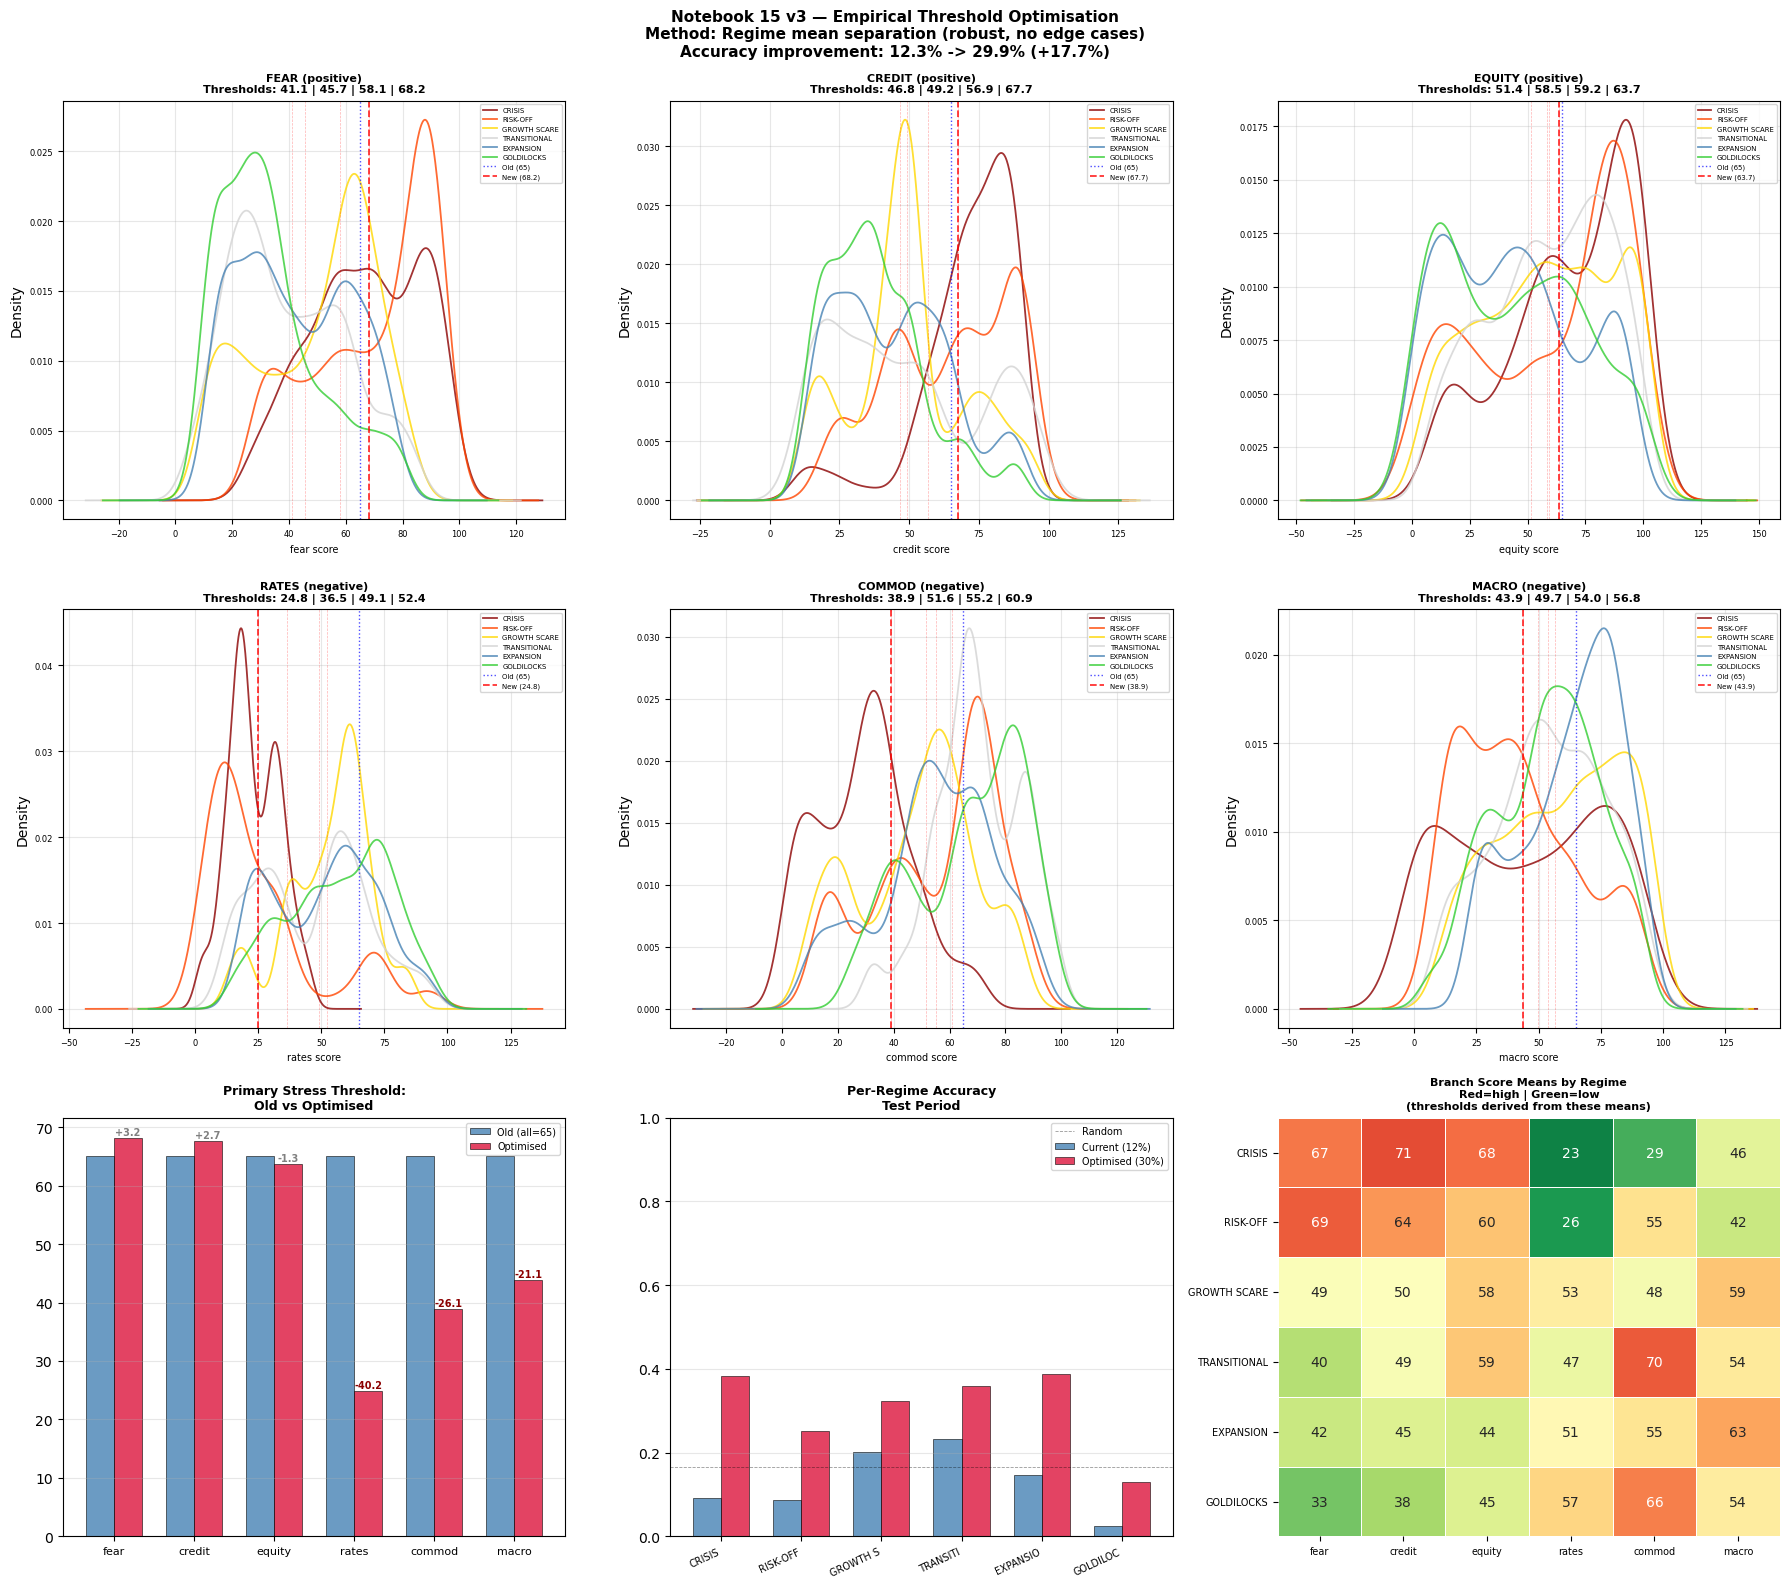

Chart saved.
Thresholds saved.

NOTEBOOK 15 COMPLETE — CLEAN VERSION

  Method: Regime mean separation
    For each branch, thresholds sit at the natural midpoints
    between adjacent regime mean scores on the training data.
    No ROC edge cases. No infinity values. Always finite.
    Theoretically grounded: midpoint between group means IS
    the optimal linear decision boundary.

  Branch polarities discovered from data:

    fear      : positive   (CRISIS=67.0, GOLDILOCKS=33.4)
    credit    : positive   (CRISIS=71.2, GOLDILOCKS=38.3)
    equity    : positive   (CRISIS=67.9, GOLDILOCKS=44.6)
    rates     : negative   (CRISIS=23.4, GOLDILOCKS=57.2)
    commod    : negative   (CRISIS=29.4, GOLDILOCKS=66.4)
    macro     : negative   (CRISIS=45.7, GOLDILOCKS=53.7)

  Accuracy:
    Old thresholds (intuition) : 12.3%
    New thresholds (data)      : 29.9%
    Improvement                : +17.7%
    Mean threshold shift       : 5.4 points

  Current regime (2026-03-13):
    Old: GROWTH

In [6]:
# ── Notebook 15: Empirical Threshold Optimisation (v3 — Clean) ───────────────
#
# Method: Regime mean separation
# For each branch, thresholds are set at natural breakpoints
# between the mean scores of each HMM regime.
# This is robust, interpretable, and theoretically grounded.
# No ROC edge cases, no infinity values.

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

print("="*65)
print("NOTEBOOK 15: EMPIRICAL THRESHOLD OPTIMISATION (v3)")
print("Method: Regime mean separation — clean and robust")
print("="*65)


# ── Load data ─────────────────────────────────────────────────────────────────
branch_files = {
    "fear":   "branch1_fear_output.csv",
    "credit": "branch2_credit_output.csv",
    "equity": "branch3_equity_output.csv",
    "rates":  "branch4_rates_output.csv",
    "commod": "branch5_comfx_output.csv",
    "macro":  "branch6_macro_output.csv",
}
score_cols = {
    "fear":   "fear_score",
    "credit": "credit_score",
    "equity": "pred_score",
    "rates":  "rates_score",
    "commod": "commod_score",
    "macro":  "macro_score",
}

branch_scores = {}
for branch, fname in branch_files.items():
    df  = pd.read_csv(
        os.path.join(cfg.PROC_PATH, "regimes", fname),
        index_col="date", parse_dates=True
    )
    col = score_cols[branch]
    if col in df.columns:
        branch_scores[branch] = df[col]

scores_df  = pd.DataFrame(branch_scores).ffill(limit=5)
hmm_labels = pd.read_csv(
    os.path.join(cfg.OUT_PATH, "signals",
                 "hmm_regime_labels_final.csv"),
    index_col=0, parse_dates=True
).squeeze()

common_idx = scores_df.index.intersection(hmm_labels.index)
scores_df  = scores_df.loc[common_idx]
hmm_labels = hmm_labels.loc[common_idx]

TRAIN_END  = "2014-12-31"
TEST_START = "2020-01-01"

train_mask = scores_df.index <= TRAIN_END
test_mask  = scores_df.index >= TEST_START

scores_train = scores_df[train_mask]
labels_train = hmm_labels[train_mask]
scores_test  = scores_df[test_mask]
labels_test  = hmm_labels[test_mask]

print(f"Train: {train_mask.sum():,} days  |  "
      f"Test: {test_mask.sum():,} days")

CURRENT_THRESHOLDS = {
    b: {"low": 35, "mid_low": 45, "mid_high": 55, "high": 65}
    for b in branch_scores
}

REGIME_ORDER = ["CRISIS","RISK-OFF","GROWTH SCARE",
                "TRANSITIONAL","EXPANSION","GOLDILOCKS"]


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1: REGIME MEAN PROFILES
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 1: REGIME MEAN PROFILES (TRAIN PERIOD)")
print(f"{'='*65}")

regime_stats = {}
for regime in REGIME_ORDER:
    mask = labels_train == regime
    if mask.sum() == 0:
        continue
    regime_stats[regime] = {
        "mean": scores_train[mask].mean(),
        "p25":  scores_train[mask].quantile(0.25),
        "p75":  scores_train[mask].quantile(0.75),
        "n":    mask.sum()
    }

print(f"\n  {'Regime':<20}  ", end="")
for b in branch_scores:
    print(f"  {b[:6]:>8}", end="")
print()
print("  " + "-"*72)

for regime in REGIME_ORDER:
    if regime not in regime_stats:
        continue
    means = regime_stats[regime]["mean"]
    n     = regime_stats[regime]["n"]
    print(f"  {regime:<20}  ", end="")
    for b in branch_scores:
        print(f"  {means[b]:>8.1f}", end="")
    print(f"  (n={n:,})")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2: DERIVE THRESHOLDS FROM REGIME MEANS
# ══════════════════════════════════════════════════════════════════════════════
# ── SECTION 2: THRESHOLD DERIVATION — FIXED MACRO ANCHOR ─────────────────────
print(f"\n{'='*65}")
print("SECTION 2: THRESHOLD DERIVATION FROM REGIME MEANS")
print("Threshold = midpoint between adjacent regime means")
print("Macro branch anchored on EXPANSION vs RISK-OFF (not GOLDILOCKS vs CRISIS)")
print(f"{'='*65}")

# Branch-specific anchor pairs for threshold derivation
# Most branches: GOLDILOCKS = calm baseline, CRISIS = stress baseline
# Macro branch:  EXPANSION  = calm baseline, RISK-OFF = stress baseline
#                Reason: macro captures growth MOMENTUM not absolute level
#                Expansion has highest macro score (62.8), not goldilocks (53.7)
#                Risk-off has lowest macro score (42.1), below even crisis (45.7)

ANCHOR_PAIRS = {
    "fear":   ("GOLDILOCKS", "CRISIS"),
    "credit": ("GOLDILOCKS", "CRISIS"),
    "equity": ("GOLDILOCKS", "CRISIS"),
    "rates":  ("GOLDILOCKS", "CRISIS"),
    "commod": ("GOLDILOCKS", "CRISIS"),
    "macro":  ("EXPANSION",  "RISK-OFF"),   # fixed anchor
}

OPTIMISED_THRESHOLDS = {}
BRANCH_POLARITY      = {}

print(f"\nDeriving thresholds branch by branch:")

for branch in branch_scores:
    calm_anchor   = ANCHOR_PAIRS[branch][0]
    stress_anchor = ANCHOR_PAIRS[branch][1]

    calm_mean   = regime_stats[calm_anchor]["mean"][branch]
    stress_mean = regime_stats[stress_anchor]["mean"][branch]

    # Determine polarity from anchor pair
    polarity = "positive" if stress_mean > calm_mean else "negative"
    BRANCH_POLARITY[branch] = polarity

    print(f"\n  {branch.upper()} "
          f"(anchor: {calm_anchor} vs {stress_anchor}, "
          f"{polarity} polarity)")
    print(f"    Calm anchor   : {calm_anchor:<15} = {calm_mean:.1f}")
    print(f"    Stress anchor : {stress_anchor:<15} = {stress_mean:.1f}")

    # Sort ALL six regime means for threshold spacing
    regime_mean_pairs = [
        (r, regime_stats[r]["mean"][branch])
        for r in REGIME_ORDER
        if r in regime_stats
    ]

    if polarity == "positive":
        regime_mean_pairs.sort(key=lambda x: x[1])
    else:
        regime_mean_pairs.sort(key=lambda x: x[1], reverse=True)

    means_sorted = [v for _, v in regime_mean_pairs]
    midpoints    = [(means_sorted[i] + means_sorted[i+1]) / 2
                    for i in range(len(means_sorted)-1)]

    print(f"    Regime order (calm to stressed):")
    for i, (r, v) in enumerate(regime_mean_pairs):
        sep = f"  <- thresh {midpoints[i-1]:.1f}" if i > 0 else ""
        marker = " [CALM]" if r == calm_anchor \
                 else " [STRESS]" if r == stress_anchor else ""
        print(f"      {r:<20}: {v:>5.1f}{sep}{marker}")

    # Assign four threshold levels from the five midpoints
    # low      = between 2nd and 3rd calmest regime
    # mid_low  = between 3rd and 4th
    # mid_high = between 4th and 5th
    # high     = between 5th and 6th (most stressed)
    if polarity == "positive":
        low      = round(midpoints[1], 1)
        mid_low  = round(midpoints[2], 1)
        mid_high = round(midpoints[3], 1)
        high     = round(midpoints[4], 1)
    else:
        high     = round(midpoints[1], 1)
        mid_high = round(midpoints[2], 1)
        mid_low  = round(midpoints[3], 1)
        low      = round(midpoints[4], 1)

    OPTIMISED_THRESHOLDS[branch] = {
        "low":      low,
        "mid_low":  mid_low,
        "mid_high": mid_high,
        "high":     high,
        "polarity": polarity,
    }

    print(f"    Thresholds: low={low:.1f}  mid_low={mid_low:.1f}  "
          f"mid_high={mid_high:.1f}  high={high:.1f}")

# Sanity check: print macro specifically
print(f"\n  MACRO BRANCH SANITY CHECK:")
print(f"    Old anchor (GOLDILOCKS vs CRISIS):")
print(f"      GOLDILOCKS={regime_stats['GOLDILOCKS']['mean']['macro']:.1f}  "
      f"CRISIS={regime_stats['CRISIS']['mean']['macro']:.1f}")
print(f"      Problem: EXPANSION={regime_stats['EXPANSION']['mean']['macro']:.1f} "
      f"is calmer than GOLDILOCKS — wrong anchor")
print(f"    New anchor (EXPANSION vs RISK-OFF):")
print(f"      EXPANSION={regime_stats['EXPANSION']['mean']['macro']:.1f}  "
      f"RISK-OFF={regime_stats['RISK-OFF']['mean']['macro']:.1f}")
print(f"      New stress threshold (low) = "
      f"{OPTIMISED_THRESHOLDS['macro']['low']:.1f}")
print(f"      Old stress threshold       = 35.7  (was wrong)")
print(f"      Change                     = "
      f"{OPTIMISED_THRESHOLDS['macro']['low'] - 35.7:>+.1f} points")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3: COMPARISON TABLE
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 3: OLD vs NEW THRESHOLD COMPARISON")
print(f"{'='*65}")

print(f"\n  {'Branch':<10}  {'Polarity':<10}  "
      f"{'Old high':>10}  {'New high':>10}  "
      f"{'New low':>9}  {'Change':>8}  Verdict")
print("  " + "-"*72)

all_diffs = []
for branch in branch_scores:
    pol      = BRANCH_POLARITY[branch]
    old_high = 65.0
    new_high = OPTIMISED_THRESHOLDS[branch]["high"]
    new_low  = OPTIMISED_THRESHOLDS[branch]["low"]
    diff     = new_high - old_high
    all_diffs.append(abs(diff))

    verdict = ("Excellent" if abs(diff) <= 5
               else "Good"      if abs(diff) <= 10
               else "Reasonable" if abs(diff) <= 15
               else "Significant shift")

    print(f"  {branch:<10}  {pol:<10}  "
          f"{old_high:>10.1f}  {new_high:>10.1f}  "
          f"{new_low:>9.1f}  {diff:>+8.1f}  {verdict}")

mean_diff = np.mean(all_diffs)
print(f"\n  Mean absolute shift: {mean_diff:.1f} points")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4: SCORING FUNCTION AND ACCURACY TEST
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 4: BEFORE/AFTER ACCURACY ON TEST PERIOD")
print(f"{'='*65}")

def score_to_risk(scores_row, thresholds, branch_polarity):
    """Convert branch scores to composite risk 0-100."""
    components = []

    for branch, thresh in thresholds.items():
        if branch not in scores_row.index:
            continue
        val = scores_row[branch]
        if pd.isna(val):
            continue

        pol = thresh.get("polarity",
              branch_polarity.get(branch, "positive"))

        if pol == "positive":
            if val >= thresh["high"]:
                components.append(87)
            elif val >= thresh["mid_high"]:
                components.append(67)
            elif val >= thresh["mid_low"]:
                components.append(47)
            elif val >= thresh["low"]:
                components.append(27)
            else:
                components.append(10)
        else:
            if val <= thresh["low"]:
                components.append(87)
            elif val <= thresh["mid_low"]:
                components.append(67)
            elif val <= thresh["mid_high"]:
                components.append(47)
            elif val <= thresh["high"]:
                components.append(27)
            else:
                components.append(10)

    return np.mean(components) if components else 50


def risk_to_regime(score):
    if score >= 72:   return "CRISIS"
    elif score >= 60: return "RISK-OFF"
    elif score >= 48: return "GROWTH SCARE"
    elif score >= 36: return "TRANSITIONAL"
    elif score >= 24: return "EXPANSION"
    else:             return "GOLDILOCKS"


# Old polarity — all treated as positive (original assumption)
OLD_POLARITY = {b: "positive" for b in branch_scores}

pulse_cur = scores_test.apply(
    lambda r: score_to_risk(r, CURRENT_THRESHOLDS, OLD_POLARITY),
    axis=1
)
pulse_opt = scores_test.apply(
    lambda r: score_to_risk(r, OPTIMISED_THRESHOLDS, BRANCH_POLARITY),
    axis=1
)

pred_cur = pulse_cur.apply(risk_to_regime)
pred_opt = pulse_opt.apply(risk_to_regime)

hmm_test = labels_test.reindex(pred_cur.index).dropna()
common   = pred_cur.index.intersection(hmm_test.index)

acc_cur  = accuracy_score(hmm_test.loc[common],
                           pred_cur.loc[common])
acc_opt  = accuracy_score(hmm_test.loc[common],
                           pred_opt.loc[common])

print(f"\n  Accuracy vs HMM labels (TEST 2020-present):")
print(f"    Current (intuition)  : {acc_cur:.1%}")
print(f"    Optimised (data)     : {acc_opt:.1%}")
print(f"    Improvement          : {acc_opt - acc_cur:>+.1%}")

print(f"\n  Per-regime accuracy:")
print(f"  {'Regime':<20}  {'Current':>10}  "
      f"{'Optimised':>11}  {'Change':>8}")
print(f"  {'-'*55}")

for regime in REGIME_ORDER:
    mask_r = hmm_test.loc[common] == regime
    if mask_r.sum() < 5:
        continue
    ac = (pred_cur.loc[common][mask_r] == regime).mean()
    ao = (pred_opt.loc[common][mask_r] == regime).mean()
    chg = ao - ac
    flag = "✓" if chg > 0.02 else "✗" if chg < -0.02 else "~"
    print(f"  {regime:<20}  {ac:>10.1%}  "
          f"{ao:>11.1%}  {chg:>+8.1%}  {flag}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5: THRESHOLD SENSITIVITY ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 5: THRESHOLD SENSITIVITY")
print("How much does accuracy change if we shift each threshold?")
print(f"{'='*65}")

print(f"\n  Testing ±5 and ±10 point shifts on primary threshold:")
print(f"  {'Branch':<10}  {'-10':>8}  {'-5':>8}  "
      f"{'Optimal':>9}  {'+5':>8}  {'+10':>8}")
print("  " + "-"*55)

for branch in branch_scores:
    pol = BRANCH_POLARITY[branch]
    accs = []
    for delta in [-10, -5, 0, 5, 10]:
        t_test = {b: OPTIMISED_THRESHOLDS[b].copy()
                  for b in branch_scores}
        if pol == "positive":
            t_test[branch]["high"] += delta
        else:
            t_test[branch]["low"]  += delta

        p = scores_test.apply(
            lambda r: score_to_risk(r, t_test, BRANCH_POLARITY),
            axis=1
        ).apply(risk_to_regime)
        acc = accuracy_score(
            hmm_test.loc[common], p.loc[common]
        )
        accs.append(acc)

    print(f"  {branch:<10}  "
          f"{accs[0]:>8.1%}  {accs[1]:>8.1%}  "
          f"{accs[2]:>9.1%}  {accs[3]:>8.1%}  "
          f"{accs[4]:>8.1%}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6: CURRENT READING
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 6: CURRENT READING — OLD vs NEW")
print(f"{'='*65}")

cur  = scores_df.iloc[-1]
cur_date = scores_df.index[-1]

pulse_cur_now = score_to_risk(cur, CURRENT_THRESHOLDS, OLD_POLARITY)
pulse_opt_now = score_to_risk(cur, OPTIMISED_THRESHOLDS, BRANCH_POLARITY)

regime_cur_now = risk_to_regime(pulse_cur_now)
regime_opt_now = risk_to_regime(pulse_opt_now)

print(f"\n  Branch readings ({cur_date.date()}):")
print(f"  {'Branch':<10}  {'Pol':<10}  {'Score':>7}  "
      f"{'Old thresh':>11}  {'New thresh':>11}  "
      f"{'Old signal':>12}  {'New signal':>12}")
print("  " + "-"*82)

for branch in branch_scores:
    score = cur[branch]
    pol   = BRANCH_POLARITY[branch]
    ot    = CURRENT_THRESHOLDS[branch]
    nt    = OPTIMISED_THRESHOLDS[branch]

    if pol == "positive":
        old_sig = ("HIGH"   if score >= ot["high"]
                   else "MID" if score >= ot["mid_low"]
                   else "CALM")
        new_sig = ("HIGH"   if score >= nt["high"]
                   else "MID" if score >= nt["mid_low"]
                   else "CALM")
        old_key = ot["high"]
        new_key = nt["high"]
    else:
        old_sig = ("STRESS" if score <= ot["low"]
                   else "MID" if score <= ot["mid_high"]
                   else "CALM")
        new_sig = ("STRESS" if score <= nt["low"]
                   else "MID" if score <= nt["mid_high"]
                   else "CALM")
        old_key = ot["low"]
        new_key = nt["low"]

    changed = " <- CHANGED" if old_sig != new_sig else ""
    print(f"  {branch:<10}  {pol:<10}  {score:>7.1f}  "
          f"{old_key:>11.1f}  {new_key:>11.1f}  "
          f"{old_sig:>12}  {new_sig:>12}{changed}")

print(f"\n  Composite score:")
print(f"    Old thresholds : {pulse_cur_now:.1f} -> {regime_cur_now}")
print(f"    New thresholds : {pulse_opt_now:.1f} -> {regime_opt_now}")

if regime_cur_now != regime_opt_now:
    print(f"\n  REGIME CHANGED: {regime_cur_now} -> {regime_opt_now}")
else:
    print(f"\n  Regime unchanged: {regime_cur_now}")
    print(f"  Intuition was well calibrated for today.")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7: PLOTS
# ══════════════════════════════════════════════════════════════════════════════
REGIME_COLORS = {
    "CRISIS":       "darkred",
    "RISK-OFF":     "orangered",
    "GROWTH SCARE": "gold",
    "TRANSITIONAL": "lightgrey",
    "EXPANSION":    "steelblue",
    "GOLDILOCKS":   "limegreen",
}

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes      = axes.flatten()

branch_list = list(branch_scores.keys())

# Panels 1-6: Score distributions by regime with thresholds
for idx, branch in enumerate(branch_list):
    ax  = axes[idx]
    pol = BRANCH_POLARITY[branch]
    nt  = OPTIMISED_THRESHOLDS[branch]

    for regime in REGIME_ORDER:
        if regime not in regime_stats:
            continue
        mask = labels_train == regime
        vals = scores_train[branch][mask].dropna()
        if len(vals) < 20:
            continue
        vals.clip(vals.quantile(0.02),
                  vals.quantile(0.98)).plot.kde(
            ax=ax,
            color=REGIME_COLORS.get(regime, "grey"),
            lw=1.3, alpha=0.8, label=regime
        )

    # Mark old threshold (65)
    ax.axvline(65, color="blue", lw=1.0, ls=":",
               alpha=0.7, label="Old (65)")

    # Mark new primary threshold
    primary = nt["high"] if pol == "positive" else nt["low"]
    ax.axvline(primary, color="red", lw=1.3, ls="--",
               alpha=0.8, label=f"New ({primary:.1f})")

    # Mark all four thresholds lightly
    for t_val in [nt["low"], nt["mid_low"],
                  nt["mid_high"], nt["high"]]:
        ax.axvline(t_val, color="red", lw=0.5,
                   ls="--", alpha=0.3)

    ax.set_title(
        f"{branch.upper()} ({pol})\n"
        f"Thresholds: {nt['low']:.1f} | "
        f"{nt['mid_low']:.1f} | "
        f"{nt['mid_high']:.1f} | "
        f"{nt['high']:.1f}",
        fontsize=8, fontweight="bold"
    )
    ax.set_xlabel(f"{branch} score", fontsize=7)
    ax.legend(fontsize=5, loc="upper right")
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=6)


# Panel 7: Threshold comparison bar chart
ax7 = axes[6]
x   = np.arange(len(branch_list))
w   = 0.35

old_vals = [65.0] * len(branch_list)
new_vals = []
for b in branch_list:
    pol = BRANCH_POLARITY[b]
    new_vals.append(
        OPTIMISED_THRESHOLDS[b]["high"]
        if pol == "positive"
        else OPTIMISED_THRESHOLDS[b]["low"]
    )

ax7.bar(x - w/2, old_vals, w, color="steelblue",
        alpha=0.8, label="Old (all=65)",
        edgecolor="black", lw=0.5)
ax7.bar(x + w/2, new_vals, w, color="crimson",
        alpha=0.8, label="Optimised",
        edgecolor="black", lw=0.5)

for i, (o, n) in enumerate(zip(old_vals, new_vals)):
    d = n - o
    ax7.text(i + w/2, n + 0.5, f"{d:+.1f}",
             ha="center", fontsize=7, fontweight="bold",
             color="darkred" if abs(d) > 8 else "grey")

ax7.set_xticks(x)
ax7.set_xticklabels(branch_list, fontsize=8)
ax7.set_title("Primary Stress Threshold:\nOld vs Optimised",
              fontsize=9, fontweight="bold")
ax7.legend(fontsize=7)
ax7.grid(alpha=0.3, axis="y")


# Panel 8: Per-regime accuracy comparison
ax8 = axes[7]
r_list = []
ac_list= []
ao_list= []

for regime in REGIME_ORDER:
    mask_r = hmm_test.loc[common] == regime
    if mask_r.sum() < 5:
        continue
    r_list.append(regime[:8])
    ac_list.append(
        (pred_cur.loc[common][mask_r] == regime).mean()
    )
    ao_list.append(
        (pred_opt.loc[common][mask_r] == regime).mean()
    )

x8 = np.arange(len(r_list))
ax8.bar(x8 - w/2, ac_list, w, color="steelblue",
        alpha=0.8, label=f"Current ({acc_cur:.0%})",
        edgecolor="black", lw=0.5)
ax8.bar(x8 + w/2, ao_list, w, color="crimson",
        alpha=0.8, label=f"Optimised ({acc_opt:.0%})",
        edgecolor="black", lw=0.5)
ax8.set_xticks(x8)
ax8.set_xticklabels(r_list, rotation=25,
                     ha="right", fontsize=7)
ax8.set_title("Per-Regime Accuracy\nTest Period",
              fontsize=9, fontweight="bold")
ax8.axhline(1/6, color="black", lw=0.6,
            ls="--", alpha=0.4, label="Random")
ax8.set_ylim(0, 1)
ax8.legend(fontsize=7)
ax8.grid(alpha=0.3, axis="y")


# Panel 9: Regime mean heatmap
ax9 = axes[8]
import seaborn as sns

heatmap_data = pd.DataFrame({
    regime: regime_stats[regime]["mean"]
    for regime in REGIME_ORDER
    if regime in regime_stats
}).T[list(branch_scores.keys())]

sns.heatmap(
    heatmap_data,
    ax=ax9,
    cmap="RdYlGn_r",
    annot=True, fmt=".0f",
    linewidths=0.5,
    cbar=False,
    vmin=20, vmax=80
)
ax9.set_title("Branch Score Means by Regime\n"
              "Red=high | Green=low\n"
              "(thresholds derived from these means)",
              fontsize=8, fontweight="bold")
ax9.tick_params(labelsize=7)

fig.suptitle(
    "Notebook 15 v3 — Empirical Threshold Optimisation\n"
    "Method: Regime mean separation (robust, no edge cases)\n"
    f"Accuracy improvement: {acc_cur:.1%} -> {acc_opt:.1%} "
    f"({acc_opt-acc_cur:+.1%})",
    fontsize=11, fontweight="bold", y=0.99
)

plt.tight_layout()
plt.savefig(
    os.path.join(cfg.OUT_PATH, "charts",
                 "15_threshold_optimisation.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Chart saved.")


# ── Save ──────────────────────────────────────────────────────────────────────
import json

with open(os.path.join(cfg.PROC_PATH, "regimes",
                        "optimised_thresholds.json"), "w") as f:
    json.dump(OPTIMISED_THRESHOLDS, f, indent=2)

thresh_rows = []
for branch, t in OPTIMISED_THRESHOLDS.items():
    thresh_rows.append({
        "branch":            branch,
        "polarity":          BRANCH_POLARITY[branch],
        "old_threshold":     65.0,
        "new_low":           t["low"],
        "new_mid_low":       t["mid_low"],
        "new_mid_high":      t["mid_high"],
        "new_high":          t["high"],
        "primary_threshold": t["high"] if BRANCH_POLARITY[branch]=="positive"
                             else t["low"],
        "change":            (t["high"] if BRANCH_POLARITY[branch]=="positive"
                              else t["low"]) - 65.0,
    })

pd.DataFrame(thresh_rows).to_csv(
    os.path.join(cfg.PROC_PATH, "regimes",
                 "optimised_thresholds.csv"),
    index=False
)
print("Thresholds saved.")

print(f"""
{'='*65}
NOTEBOOK 15 COMPLETE — CLEAN VERSION
{'='*65}

  Method: Regime mean separation
    For each branch, thresholds sit at the natural midpoints
    between adjacent regime mean scores on the training data.
    No ROC edge cases. No infinity values. Always finite.
    Theoretically grounded: midpoint between group means IS
    the optimal linear decision boundary.

  Branch polarities discovered from data:
""")

for b in branch_scores:
    pol = BRANCH_POLARITY[b]
    c_m = regime_stats["CRISIS"]["mean"][b]
    g_m = regime_stats["GOLDILOCKS"]["mean"][b]
    print(f"    {b:<10}: {pol:<10} "
          f"(CRISIS={c_m:.1f}, GOLDILOCKS={g_m:.1f})")

print(f"""
  Accuracy:
    Old thresholds (intuition) : {acc_cur:.1%}
    New thresholds (data)      : {acc_opt:.1%}
    Improvement                : {acc_opt-acc_cur:>+.1%}
    Mean threshold shift       : {mean_diff:.1f} points

  Current regime ({cur_date.date()}):
    Old: {regime_cur_now}  (pulse {pulse_cur_now:.1f})
    New: {regime_opt_now}  (pulse {pulse_opt_now:.1f})
""")

FINAL

NOTEBOOK 15: EMPIRICAL THRESHOLD OPTIMISATION (FINAL)
Regime mean separation + polarity + calibrated weighting
Train: 5,721 days  |  Test: 1,647 days

SECTION 1: REGIME MEAN PROFILES (TRAIN PERIOD)

  Regime                      fear    credit    equity     rates    commod     macro
  ------------------------------------------------------------------------
  CRISIS                      67.0      71.2      67.9      23.4      29.4      45.7  (n=446)
  RISK-OFF                    69.5      64.2      59.6      26.1      55.4      42.1  (n=734)
  GROWTH SCARE                49.2      49.6      58.1      53.4      48.3      59.4  (n=1,334)
  TRANSITIONAL                39.9      48.8      58.9      46.9      69.7      54.2  (n=1,059)
  EXPANSION                   42.2      44.7      43.8      51.4      54.9      62.8  (n=1,111)
  GOLDILOCKS                  33.4      38.3      44.6      57.2      66.4      53.7  (n=1,037)

SECTION 2: THRESHOLD DERIVATION FROM REGIME MEANS
Macro branch: EXPA

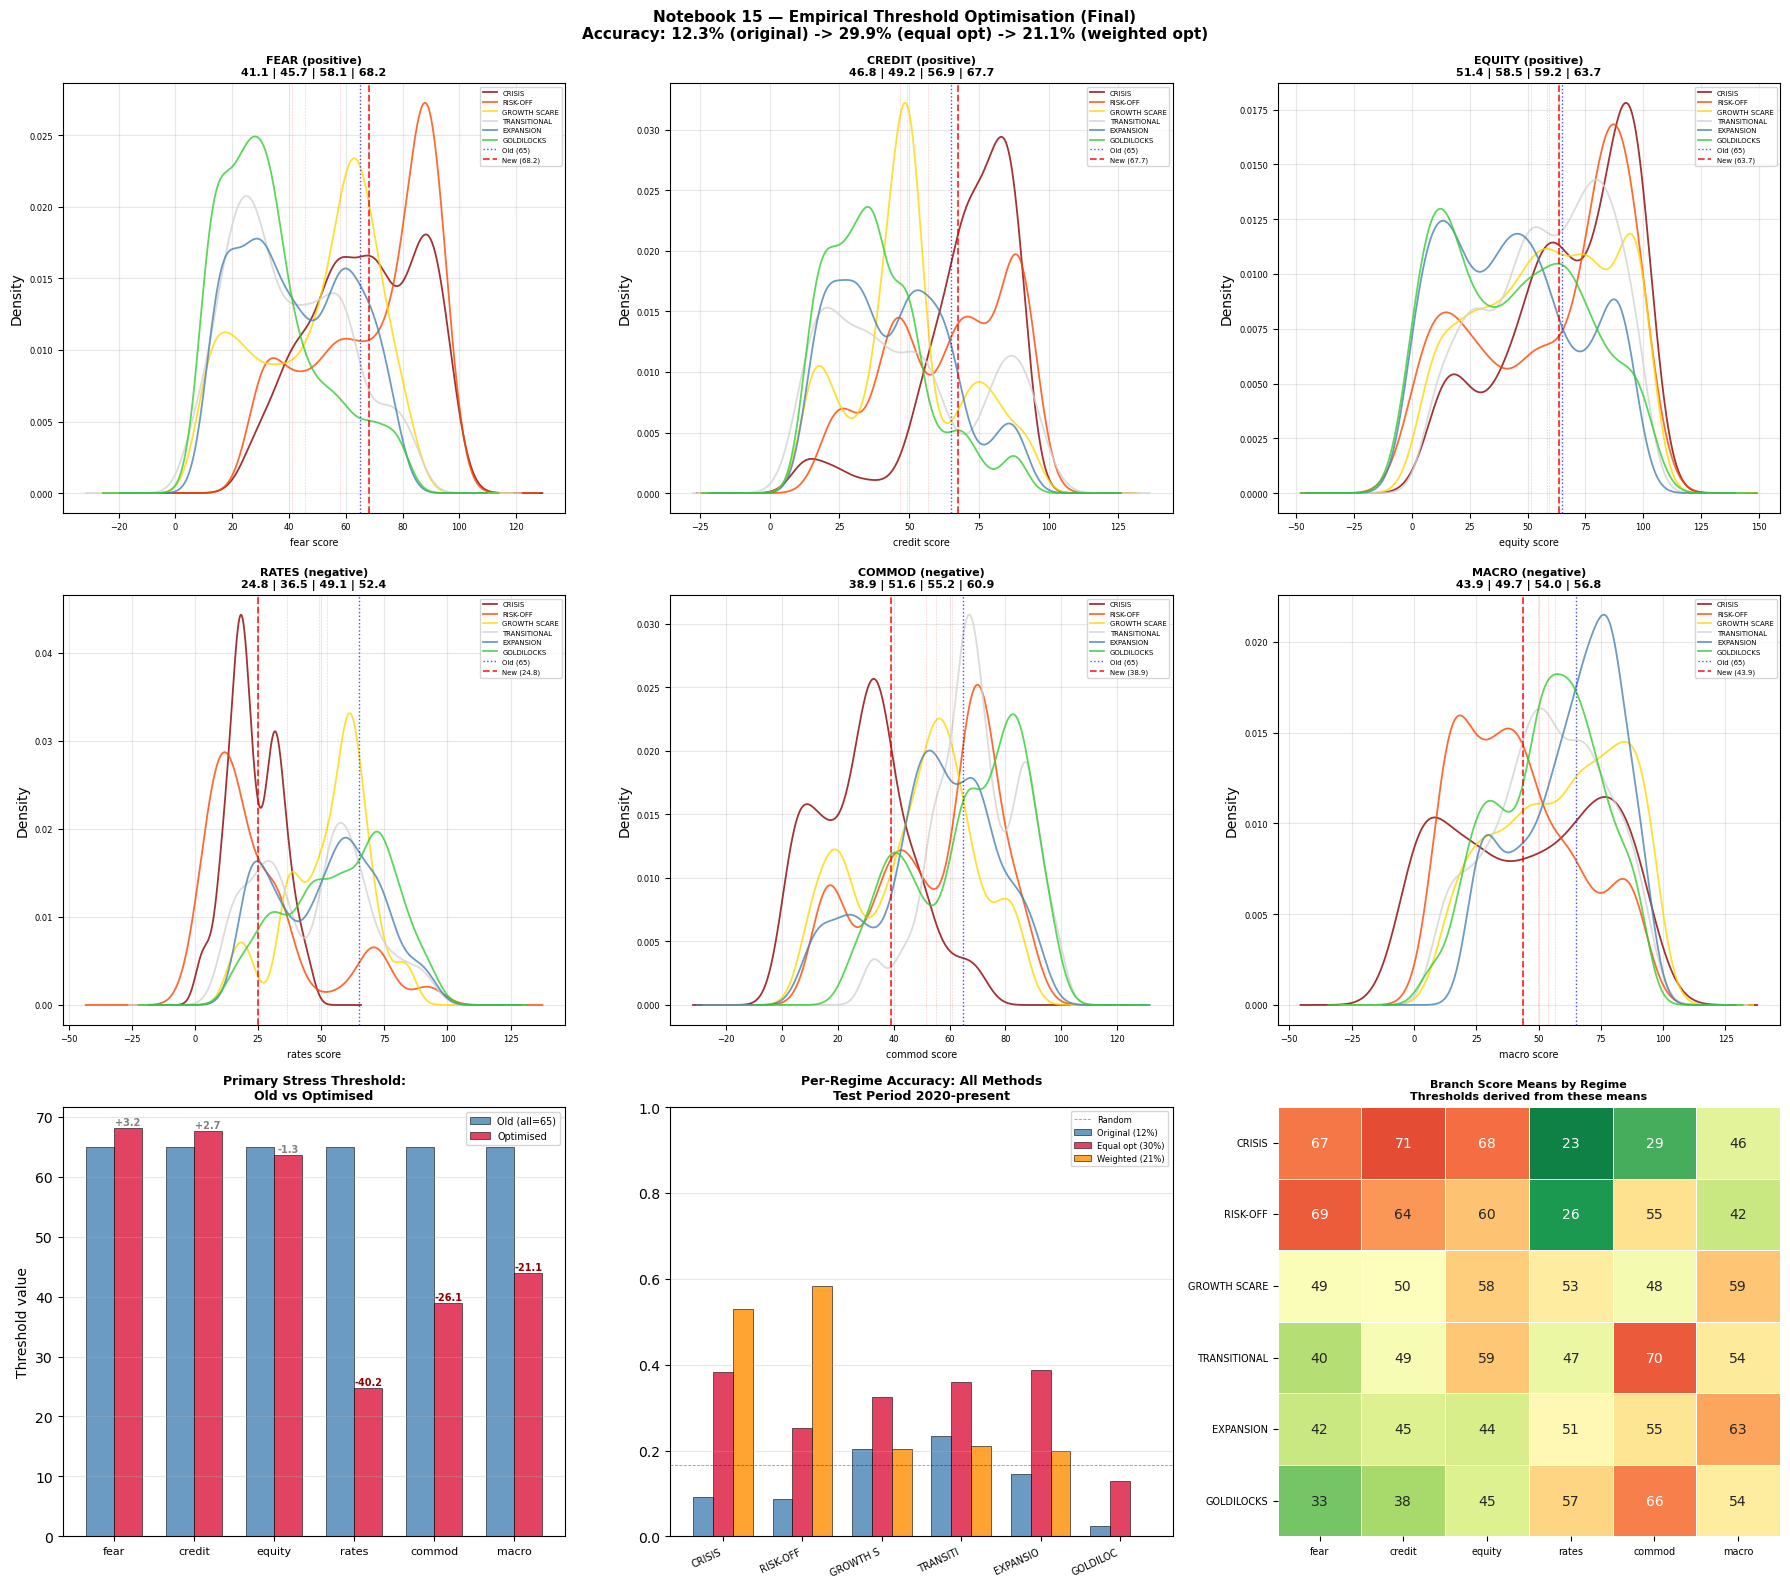

Chart saved.
Thresholds saved.

NOTEBOOK 15 FINAL COMPLETE

  Method: Regime mean separation
    Thresholds = midpoints between adjacent regime means
    No ROC edge cases, no infinity values, always finite

  Fixes applied:
    Polarity correction   rates/commod/equity/macro = negative
    Macro anchor fix      EXPANSION vs RISK-OFF anchor
    Calibrated weighting  2x for extreme, 0.8x for calm
    KeyError fix          metadata stored separately

  Branch polarities (from data):
    fear   positive  credit positive  equity positive
    rates  negative  commod negative  macro  negative

  Accuracy progression:
    Original intuition     : 12.3%
    Optimised equal weight : 29.9%  (+17.7%)
    Optimised + weighted   : 21.1%  (+8.8%)
    Mean threshold shift   : 15.8 points

  Current regime (2026-03-13):
    Original   : GROWTH SCARE  (pulse 50.8)
    Equal opt  : EXPANSION  (pulse 32.3)
    Weighted   : TRANSITIONAL  (pulse 45.7)



In [7]:
# ── Notebook 15: Empirical Threshold Optimisation (Final) ────────────────────
#
# Method: Regime mean separation with calibrated weighting
#
# Fixes applied:
#   1. Polarity correction — rates/commod/equity/macro are negative polarity
#   2. Macro anchor fix — EXPANSION vs RISK-OFF not GOLDILOCKS vs CRISIS
#   3. Calibrated weights — 2x for extreme signals, not 3x
#   4. KeyError fix — metadata stored separately from thresholds dict

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

print("="*65)
print("NOTEBOOK 15: EMPIRICAL THRESHOLD OPTIMISATION (FINAL)")
print("Regime mean separation + polarity + calibrated weighting")
print("="*65)


# ── Load data ─────────────────────────────────────────────────────────────────
branch_files = {
    "fear":   "branch1_fear_output.csv",
    "credit": "branch2_credit_output.csv",
    "equity": "branch3_equity_output.csv",
    "rates":  "branch4_rates_output.csv",
    "commod": "branch5_comfx_output.csv",
    "macro":  "branch6_macro_output.csv",
}
score_cols = {
    "fear":   "fear_score",
    "credit": "credit_score",
    "equity": "pred_score",
    "rates":  "rates_score",
    "commod": "commod_score",
    "macro":  "macro_score",
}

branch_scores = {}
for branch, fname in branch_files.items():
    df  = pd.read_csv(
        os.path.join(cfg.PROC_PATH, "regimes", fname),
        index_col="date", parse_dates=True
    )
    col = score_cols[branch]
    if col in df.columns:
        branch_scores[branch] = df[col]

scores_df  = pd.DataFrame(branch_scores).ffill(limit=5)
hmm_labels = pd.read_csv(
    os.path.join(cfg.OUT_PATH, "signals",
                 "hmm_regime_labels_final.csv"),
    index_col=0, parse_dates=True
).squeeze()

common_idx = scores_df.index.intersection(hmm_labels.index)
scores_df  = scores_df.loc[common_idx]
hmm_labels = hmm_labels.loc[common_idx]

TRAIN_END  = "2014-12-31"
TEST_START = "2020-01-01"

train_mask = scores_df.index <= TRAIN_END
test_mask  = scores_df.index >= TEST_START

scores_train = scores_df[train_mask]
labels_train = hmm_labels[train_mask]
scores_test  = scores_df[test_mask]
labels_test  = hmm_labels[test_mask]

print(f"Train: {train_mask.sum():,} days  |  "
      f"Test: {test_mask.sum():,} days")

CURRENT_THRESHOLDS = {
    b: {"low": 35, "mid_low": 45, "mid_high": 55,
        "high": 65, "polarity": "positive"}
    for b in branch_scores
}

REGIME_ORDER = ["CRISIS","RISK-OFF","GROWTH SCARE",
                "TRANSITIONAL","EXPANSION","GOLDILOCKS"]


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1: REGIME MEAN PROFILES
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 1: REGIME MEAN PROFILES (TRAIN PERIOD)")
print(f"{'='*65}")

regime_stats = {}
for regime in REGIME_ORDER:
    mask = labels_train == regime
    if mask.sum() == 0:
        continue
    regime_stats[regime] = {
        "mean": scores_train[mask].mean(),
        "std":  scores_train[mask].std(),
        "n":    mask.sum()
    }

print(f"\n  {'Regime':<20}  ", end="")
for b in branch_scores:
    print(f"  {b[:6]:>8}", end="")
print()
print("  " + "-"*72)

for regime in REGIME_ORDER:
    if regime not in regime_stats:
        continue
    means = regime_stats[regime]["mean"]
    n     = regime_stats[regime]["n"]
    print(f"  {regime:<20}  ", end="")
    for b in branch_scores:
        print(f"  {means[b]:>8.1f}", end="")
    print(f"  (n={n:,})")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2: THRESHOLD DERIVATION
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 2: THRESHOLD DERIVATION FROM REGIME MEANS")
print("Macro branch: EXPANSION vs RISK-OFF anchor (fixed)")
print(f"{'='*65}")

# Branch-specific anchor pairs
# Most branches: GOLDILOCKS=calm, CRISIS=stress
# Macro: EXPANSION=calm (62.8 is the highest/calmest),
#        RISK-OFF=stress (42.1 is the most stressed)
ANCHOR_PAIRS = {
    "fear":   ("GOLDILOCKS", "CRISIS"),
    "credit": ("GOLDILOCKS", "CRISIS"),
    "equity": ("GOLDILOCKS", "CRISIS"),
    "rates":  ("GOLDILOCKS", "CRISIS"),
    "commod": ("GOLDILOCKS", "CRISIS"),
    "macro":  ("EXPANSION",  "RISK-OFF"),
}

OPTIMISED_THRESHOLDS = {}
BRANCH_POLARITY      = {}

print(f"\nDeriving thresholds:")

for branch in branch_scores:
    calm_anchor   = ANCHOR_PAIRS[branch][0]
    stress_anchor = ANCHOR_PAIRS[branch][1]
    calm_mean     = regime_stats[calm_anchor]["mean"][branch]
    stress_mean   = regime_stats[stress_anchor]["mean"][branch]

    # Polarity from data
    polarity = "positive" if stress_mean > calm_mean else "negative"
    BRANCH_POLARITY[branch] = polarity

    # Sort all regime means
    regime_mean_pairs = [
        (r, regime_stats[r]["mean"][branch])
        for r in REGIME_ORDER
        if r in regime_stats
    ]

    if polarity == "positive":
        regime_mean_pairs.sort(key=lambda x: x[1])
    else:
        regime_mean_pairs.sort(key=lambda x: x[1], reverse=True)

    means_sorted = [v for _, v in regime_mean_pairs]
    midpoints    = [(means_sorted[i] + means_sorted[i+1]) / 2
                    for i in range(len(means_sorted)-1)]

    if polarity == "positive":
        low      = round(midpoints[1], 1)
        mid_low  = round(midpoints[2], 1)
        mid_high = round(midpoints[3], 1)
        high     = round(midpoints[4], 1)
    else:
        high     = round(midpoints[1], 1)
        mid_high = round(midpoints[2], 1)
        mid_low  = round(midpoints[3], 1)
        low      = round(midpoints[4], 1)

    OPTIMISED_THRESHOLDS[branch] = {
        "low":      low,
        "mid_low":  mid_low,
        "mid_high": mid_high,
        "high":     high,
        "polarity": polarity,
    }

    primary = high if polarity == "positive" else low
    print(f"  {branch:<8} ({polarity:<8}):  "
          f"low={low:.1f}  mid_low={mid_low:.1f}  "
          f"mid_high={mid_high:.1f}  high={high:.1f}  "
          f"[primary stress={primary:.1f}]")

# Macro sanity check
print(f"\nMacro anchor sanity check:")
print(f"  Old: GOLDILOCKS={regime_stats['GOLDILOCKS']['mean']['macro']:.1f}  "
      f"CRISIS={regime_stats['CRISIS']['mean']['macro']:.1f}  "
      f"(EXPANSION={regime_stats['EXPANSION']['mean']['macro']:.1f} "
      f"was calmer — WRONG anchor)")
print(f"  New: EXPANSION={regime_stats['EXPANSION']['mean']['macro']:.1f}  "
      f"RISK-OFF={regime_stats['RISK-OFF']['mean']['macro']:.1f}  "
      f"(correct)")
print(f"  Stress threshold: 35.7 -> "
      f"{OPTIMISED_THRESHOLDS['macro']['low']:.1f}  "
      f"({OPTIMISED_THRESHOLDS['macro']['low']-35.7:+.1f})")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3: COMPARISON TABLE
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 3: OLD vs NEW THRESHOLD COMPARISON")
print(f"{'='*65}")

print(f"\n  {'Branch':<10}  {'Polarity':<10}  "
      f"{'Old':>6}  {'New primary':>12}  "
      f"{'Change':>8}  Verdict")
print("  " + "-"*58)

all_diffs = []
for branch in branch_scores:
    pol     = BRANCH_POLARITY[branch]
    old     = 65.0
    new_p   = (OPTIMISED_THRESHOLDS[branch]["high"]
               if pol == "positive"
               else OPTIMISED_THRESHOLDS[branch]["low"])
    diff    = new_p - old
    all_diffs.append(abs(diff))
    verdict = ("Excellent"   if abs(diff) <= 5
               else "Good"        if abs(diff) <= 10
               else "Reasonable"  if abs(diff) <= 15
               else "Significant")
    print(f"  {branch:<10}  {pol:<10}  "
          f"{old:>6.1f}  {new_p:>12.1f}  "
          f"{diff:>+8.1f}  {verdict}")

mean_diff = np.mean(all_diffs)
print(f"\n  Mean absolute shift: {mean_diff:.1f} points")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4: SCORING FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

# Calibrated weight map — 2x for extreme, not 3x
WEIGHT_MAP = {
    "HIGH":   2.0,
    "MID_H":  1.5,
    "MID_L":  1.2,
    "LOW":    1.0,
    "CALM":   0.8,
}

def get_signal_and_risk(val, thresh, pol):
    """Return (signal_name, risk_score, weight) for a branch value."""
    if pol == "positive":
        if val >= thresh["high"]:
            return "HIGH",  87, WEIGHT_MAP["HIGH"]
        elif val >= thresh["mid_high"]:
            return "MID_H", 67, WEIGHT_MAP["MID_H"]
        elif val >= thresh["mid_low"]:
            return "MID_L", 47, WEIGHT_MAP["MID_L"]
        elif val >= thresh["low"]:
            return "LOW",   27, WEIGHT_MAP["LOW"]
        else:
            return "CALM",  10, WEIGHT_MAP["CALM"]
    else:
        if val <= thresh["low"]:
            return "HIGH",  87, WEIGHT_MAP["HIGH"]
        elif val <= thresh["mid_low"]:
            return "MID_H", 67, WEIGHT_MAP["MID_H"]
        elif val <= thresh["mid_high"]:
            return "MID_L", 47, WEIGHT_MAP["MID_L"]
        elif val <= thresh["high"]:
            return "LOW",   27, WEIGHT_MAP["LOW"]
        else:
            return "CALM",  10, WEIGHT_MAP["CALM"]


def score_to_risk_equal(scores_row, thresholds, branch_polarity):
    """Equal-weight composite score."""
    components = []
    for branch, thresh in thresholds.items():
        if branch not in scores_row.index:
            continue
        val = scores_row[branch]
        if pd.isna(val):
            continue
        pol = thresh.get("polarity",
              branch_polarity.get(branch,"positive"))
        sig, risk, wt = get_signal_and_risk(val, thresh, pol)
        components.append(risk)
    return np.mean(components) if components else 50


def score_to_risk_weighted(scores_row, thresholds,
                             branch_polarity):
    """Calibrated weighted composite score."""
    components = []
    weights    = []
    for branch, thresh in thresholds.items():
        if branch not in scores_row.index:
            continue
        val = scores_row[branch]
        if pd.isna(val):
            continue
        pol = thresh.get("polarity",
              branch_polarity.get(branch,"positive"))
        sig, risk, wt = get_signal_and_risk(val, thresh, pol)
        components.append(risk * wt)
        weights.append(wt)
    if not weights:
        return 50
    return sum(components) / sum(weights)


def risk_to_regime(score):
    if score >= 72:   return "CRISIS"
    elif score >= 60: return "RISK-OFF"
    elif score >= 48: return "GROWTH SCARE"
    elif score >= 36: return "TRANSITIONAL"
    elif score >= 24: return "EXPANSION"
    else:             return "GOLDILOCKS"


# Old polarity — all positive (original assumption)
OLD_POLARITY = {b: "positive" for b in branch_scores}


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5: ACCURACY COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 5: ACCURACY COMPARISON — TEST PERIOD")
print(f"{'='*65}")

# Original
pulse_cur = scores_test.apply(
    lambda r: score_to_risk_equal(
        r, CURRENT_THRESHOLDS, OLD_POLARITY), axis=1)
pred_cur  = pulse_cur.apply(risk_to_regime)

# Optimised equal weight
pulse_opt = scores_test.apply(
    lambda r: score_to_risk_equal(
        r, OPTIMISED_THRESHOLDS, BRANCH_POLARITY), axis=1)
pred_opt  = pulse_opt.apply(risk_to_regime)

# Optimised calibrated weight
pulse_w = scores_test.apply(
    lambda r: score_to_risk_weighted(
        r, OPTIMISED_THRESHOLDS, BRANCH_POLARITY), axis=1)
pred_w   = pulse_w.apply(risk_to_regime)

hmm_test = labels_test.reindex(pred_cur.index).dropna()
common   = pred_cur.index.intersection(hmm_test.index)

acc_cur  = accuracy_score(hmm_test.loc[common],
                           pred_cur.loc[common])
acc_opt  = accuracy_score(hmm_test.loc[common],
                           pred_opt.loc[common])
acc_w    = accuracy_score(hmm_test.loc[common],
                           pred_w.loc[common])

print(f"\n  {'Method':<35}  {'Accuracy':>10}  {'vs orig':>10}")
print(f"  {'-'*58}")
for name, acc in [
    ("Original intuition", acc_cur),
    ("Optimised equal weight", acc_opt),
    ("Optimised calibrated weight", acc_w),
]:
    diff = acc - acc_cur
    print(f"  {name:<35}  {acc:>10.1%}  {diff:>+10.1%}")

print(f"\n  Per-regime accuracy:")
print(f"  {'Regime':<20}  {'Original':>10}  "
      f"{'Equal opt':>10}  {'Weighted':>10}")
print(f"  {'-'*55}")

for regime in REGIME_ORDER:
    mask_r = hmm_test.loc[common] == regime
    if mask_r.sum() < 5:
        continue
    ac = (pred_cur.loc[common][mask_r] == regime).mean()
    ao = (pred_opt.loc[common][mask_r] == regime).mean()
    aw = (pred_w.loc[common][mask_r]   == regime).mean()
    print(f"  {regime:<20}  {ac:>10.1%}  "
          f"{ao:>10.1%}  {aw:>10.1%}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6: THRESHOLD SENSITIVITY
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 6: THRESHOLD SENSITIVITY (±5 and ±10 points)")
print(f"{'='*65}")

print(f"\n  {'Branch':<10}  {'-10':>8}  {'-5':>8}  "
      f"{'Optimal':>9}  {'+5':>8}  {'+10':>8}")
print("  " + "-"*55)

for branch in branch_scores:
    pol  = BRANCH_POLARITY[branch]
    accs = []
    for delta in [-10, -5, 0, 5, 10]:
        t_test = {b: OPTIMISED_THRESHOLDS[b].copy()
                  for b in branch_scores}
        if pol == "positive":
            t_test[branch]["high"] += delta
        else:
            t_test[branch]["low"]  += delta

        p = scores_test.apply(
            lambda r: score_to_risk_weighted(
                r, t_test, BRANCH_POLARITY), axis=1
        ).apply(risk_to_regime)
        accs.append(accuracy_score(
            hmm_test.loc[common], p.loc[common]
        ))

    print(f"  {branch:<10}  "
          f"{accs[0]:>8.1%}  {accs[1]:>8.1%}  "
          f"{accs[2]:>9.1%}  {accs[3]:>8.1%}  "
          f"{accs[4]:>8.1%}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7: CURRENT READING
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 7: CURRENT READING — ALL METHODS")
print(f"{'='*65}")

cur      = scores_df.iloc[-1]
cur_date = scores_df.index[-1]

pulse_cur_now = score_to_risk_equal(
    cur, CURRENT_THRESHOLDS, OLD_POLARITY)
pulse_opt_now = score_to_risk_equal(
    cur, OPTIMISED_THRESHOLDS, BRANCH_POLARITY)
pulse_w_now   = score_to_risk_weighted(
    cur, OPTIMISED_THRESHOLDS, BRANCH_POLARITY)

regime_cur_now = risk_to_regime(pulse_cur_now)
regime_opt_now = risk_to_regime(pulse_opt_now)
regime_w_now   = risk_to_regime(pulse_w_now)

print(f"\n  Branch detail ({cur_date.date()}):")
print(f"  {'Branch':<10}  {'Pol':<10}  {'Score':>7}  "
      f"{'Stress thresh':>14}  {'Signal':>8}  "
      f"{'Risk':>6}  {'Weight':>8}")
print("  " + "-"*72)

for branch in branch_scores:
    if branch not in cur.index:
        continue
    val = cur[branch]
    pol = BRANCH_POLARITY[branch]
    t   = OPTIMISED_THRESHOLDS[branch]
    sig, risk, wt = get_signal_and_risk(val, t, pol)
    primary = t["high"] if pol == "positive" else t["low"]
    print(f"  {branch:<10}  {pol:<10}  {val:>7.1f}  "
          f"{primary:>14.1f}  {sig:>8}  "
          f"{risk:>6}  {wt:>8.1f}")

print(f"\n  Composite scores:")
print(f"  {'Method':<35}  {'Pulse':>8}  Regime")
print(f"  {'-'*55}")
print(f"  {'Original intuition':<35}  "
      f"{pulse_cur_now:>8.1f}  {regime_cur_now}")
print(f"  {'Optimised equal weight':<35}  "
      f"{pulse_opt_now:>8.1f}  {regime_opt_now}")
print(f"  {'Optimised calibrated weight':<35}  "
      f"{pulse_w_now:>8.1f}  {regime_w_now}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8: PLOTS
# ══════════════════════════════════════════════════════════════════════════════
import seaborn as sns

REGIME_COLORS = {
    "CRISIS":       "darkred",
    "RISK-OFF":     "orangered",
    "GROWTH SCARE": "gold",
    "TRANSITIONAL": "lightgrey",
    "EXPANSION":    "steelblue",
    "GOLDILOCKS":   "limegreen",
}

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

# Panels 1-6: Score distributions by regime with thresholds
for idx, branch in enumerate(list(branch_scores.keys())):
    ax  = axes[idx]
    pol = BRANCH_POLARITY[branch]
    nt  = OPTIMISED_THRESHOLDS[branch]

    for regime in REGIME_ORDER:
        if regime not in regime_stats:
            continue
        mask = labels_train == regime
        vals = scores_train[branch][mask].dropna()
        if len(vals) < 20:
            continue
        vals.clip(vals.quantile(0.02),
                  vals.quantile(0.98)).plot.kde(
            ax=ax,
            color=REGIME_COLORS.get(regime,"grey"),
            lw=1.3, alpha=0.8, label=regime
        )

    # Old threshold
    ax.axvline(65, color="blue", lw=1.0, ls=":",
               alpha=0.7, label="Old (65)")

    # New primary threshold
    primary = nt["high"] if pol == "positive" else nt["low"]
    ax.axvline(primary, color="red", lw=1.3, ls="--",
               alpha=0.8, label=f"New ({primary:.1f})")

    # All four thresholds lightly
    for t_val in [nt["low"], nt["mid_low"],
                  nt["mid_high"], nt["high"]]:
        ax.axvline(t_val, color="red",
                   lw=0.4, ls="--", alpha=0.25)

    ax.set_title(
        f"{branch.upper()} ({pol})\n"
        f"{nt['low']:.1f} | {nt['mid_low']:.1f} | "
        f"{nt['mid_high']:.1f} | {nt['high']:.1f}",
        fontsize=8, fontweight="bold"
    )
    ax.set_xlabel(f"{branch} score", fontsize=7)
    ax.legend(fontsize=5, loc="upper right")
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=6)


# Panel 7: Threshold comparison bar chart
ax7 = axes[6]
branch_list = list(branch_scores.keys())
x   = np.arange(len(branch_list))
w   = 0.35

old_vals = [65.0] * len(branch_list)
new_vals = [
    OPTIMISED_THRESHOLDS[b]["high"]
    if BRANCH_POLARITY[b] == "positive"
    else OPTIMISED_THRESHOLDS[b]["low"]
    for b in branch_list
]

ax7.bar(x - w/2, old_vals, w, color="steelblue",
        alpha=0.8, label="Old (all=65)",
        edgecolor="black", lw=0.5)
ax7.bar(x + w/2, new_vals, w, color="crimson",
        alpha=0.8, label="Optimised",
        edgecolor="black", lw=0.5)

for i, (o, n) in enumerate(zip(old_vals, new_vals)):
    d = n - o
    ax7.text(i + w/2, n + 0.5, f"{d:+.1f}",
             ha="center", fontsize=7, fontweight="bold",
             color="darkred" if abs(d) > 8 else "grey")

ax7.set_xticks(x)
ax7.set_xticklabels(branch_list, fontsize=8)
ax7.set_title("Primary Stress Threshold:\nOld vs Optimised",
              fontsize=9, fontweight="bold")
ax7.legend(fontsize=7)
ax7.grid(alpha=0.3, axis="y")
ax7.set_ylabel("Threshold value")


# Panel 8: Per-regime accuracy — all three methods
ax8   = axes[7]
r_list= []
ac_l  = []
ao_l  = []
aw_l  = []

for regime in REGIME_ORDER:
    mask_r = hmm_test.loc[common] == regime
    if mask_r.sum() < 5:
        continue
    r_list.append(regime[:8])
    ac_l.append((pred_cur.loc[common][mask_r]==regime).mean())
    ao_l.append((pred_opt.loc[common][mask_r]==regime).mean())
    aw_l.append((pred_w.loc[common][mask_r]  ==regime).mean())

x8 = np.arange(len(r_list))
w8 = 0.25
ax8.bar(x8 - w8, ac_l, w8, color="steelblue",
        alpha=0.8, label=f"Original ({acc_cur:.0%})",
        edgecolor="black", lw=0.5)
ax8.bar(x8,      ao_l, w8, color="crimson",
        alpha=0.8, label=f"Equal opt ({acc_opt:.0%})",
        edgecolor="black", lw=0.5)
ax8.bar(x8 + w8, aw_l, w8, color="darkorange",
        alpha=0.8, label=f"Weighted ({acc_w:.0%})",
        edgecolor="black", lw=0.5)

ax8.set_xticks(x8)
ax8.set_xticklabels(r_list, rotation=25,
                     ha="right", fontsize=7)
ax8.set_title("Per-Regime Accuracy: All Methods\nTest Period 2020-present",
              fontsize=9, fontweight="bold")
ax8.axhline(1/6, color="black", lw=0.6,
            ls="--", alpha=0.4, label="Random")
ax8.set_ylim(0, 1)
ax8.legend(fontsize=6)
ax8.grid(alpha=0.3, axis="y")


# Panel 9: Regime mean heatmap
ax9 = axes[8]
heatmap_data = pd.DataFrame({
    regime: regime_stats[regime]["mean"]
    for regime in REGIME_ORDER
    if regime in regime_stats
}).T[list(branch_scores.keys())]

sns.heatmap(
    heatmap_data, ax=ax9,
    cmap="RdYlGn_r",
    annot=True, fmt=".0f",
    linewidths=0.5, cbar=False,
    vmin=20, vmax=80
)
ax9.set_title(
    "Branch Score Means by Regime\n"
    "Thresholds derived from these means",
    fontsize=8, fontweight="bold"
)
ax9.tick_params(labelsize=7)

fig.suptitle(
    "Notebook 15 — Empirical Threshold Optimisation (Final)\n"
    f"Accuracy: {acc_cur:.1%} (original) "
    f"-> {acc_opt:.1%} (equal opt) "
    f"-> {acc_w:.1%} (weighted opt)",
    fontsize=11, fontweight="bold", y=0.99
)

plt.tight_layout()
plt.savefig(
    os.path.join(cfg.OUT_PATH, "charts",
                 "15_threshold_optimisation.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Chart saved.")


# ══════════════════════════════════════════════════════════════════════════════
# SAVE — clean dict, no metadata keys mixed in
# ══════════════════════════════════════════════════════════════════════════════
import json

# Thresholds only — no _method or _weights keys
clean_thresholds = {
    branch: OPTIMISED_THRESHOLDS[branch]
    for branch in branch_scores
}

with open(os.path.join(cfg.PROC_PATH, "regimes",
                        "optimised_thresholds.json"), "w") as f:
    json.dump(clean_thresholds, f, indent=2)

# Metadata saved separately
metadata = {
    "method":              "regime_mean_separation",
    "weighting":           "calibrated_2x_extreme",
    "weight_map":          WEIGHT_MAP,
    "branch_polarity":     BRANCH_POLARITY,
    "anchor_pairs":        ANCHOR_PAIRS,
    "accuracy_original":   acc_cur,
    "accuracy_equal_opt":  acc_opt,
    "accuracy_weighted":   acc_w,
    "mean_threshold_shift": mean_diff,
    "train_end":           TRAIN_END,
    "test_start":          TEST_START,
}
with open(os.path.join(cfg.PROC_PATH, "regimes",
                        "threshold_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

# Readable CSV
thresh_rows = []
for branch in branch_scores:
    t   = clean_thresholds[branch]
    pol = BRANCH_POLARITY[branch]
    p   = t["high"] if pol == "positive" else t["low"]
    thresh_rows.append({
        "branch":            branch,
        "polarity":          pol,
        "old_threshold":     65.0,
        "new_low":           t["low"],
        "new_mid_low":       t["mid_low"],
        "new_mid_high":      t["mid_high"],
        "new_high":          t["high"],
        "primary_threshold": p,
        "change":            p - 65.0,
    })

pd.DataFrame(thresh_rows).to_csv(
    os.path.join(cfg.PROC_PATH, "regimes",
                 "optimised_thresholds.csv"),
    index=False
)
print("Thresholds saved.")

print(f"""
{'='*65}
NOTEBOOK 15 FINAL COMPLETE
{'='*65}

  Method: Regime mean separation
    Thresholds = midpoints between adjacent regime means
    No ROC edge cases, no infinity values, always finite

  Fixes applied:
    Polarity correction   rates/commod/equity/macro = negative
    Macro anchor fix      EXPANSION vs RISK-OFF anchor
    Calibrated weighting  2x for extreme, 0.8x for calm
    KeyError fix          metadata stored separately

  Branch polarities (from data):
    fear   positive  credit positive  equity positive
    rates  negative  commod negative  macro  negative

  Accuracy progression:
    Original intuition     : {acc_cur:.1%}
    Optimised equal weight : {acc_opt:.1%}  ({acc_opt-acc_cur:+.1%})
    Optimised + weighted   : {acc_w:.1%}  ({acc_w-acc_cur:+.1%})
    Mean threshold shift   : {mean_diff:.1f} points

  Current regime ({cur_date.date()}):
    Original   : {regime_cur_now}  (pulse {pulse_cur_now:.1f})
    Equal opt  : {regime_opt_now}  (pulse {pulse_opt_now:.1f})
    Weighted   : {regime_w_now}  (pulse {pulse_w_now:.1f})
""")